# Parte B — EDA: Evolução da Inadimplência no Brasil (2012–2024)

**Foco:** Séries históricas de inadimplência de pessoas físicas e jurídicas  
**Correlações:** Selic, IPCA, Desemprego, PIB, Endividamento das famílias  
**Fonte principal:** Banco Central do Brasil — API SGS  
**Período:** Janeiro de 2012 a Dezembro de 2024

---

## Sumário

1. [Setup e Coleta de Dados](#1)
2. [Visão Geral das Séries](#2)
3. [Análise 1 — PF vs. PJ: Comportamentos Distintos](#3)
4. [Análise 2 — Decomposição por Modalidade de Crédito](#4)
5. [Análise 3 — Ciclos Econômicos e Choques](#5)
6. [Análise 4 — Correlação com Selic e IPCA](#6)
7. [Análise 5 — Correlação com Desemprego e PIB](#7)
8. [Análise 6 — Endividamento vs. Inadimplência](#8)
9. [Análise 7 — Decomposição de Tendência e Sazonalidade](#9)
10. [Análise 8 — Modelos de Correlação com Defasagem (Cross-Correlation)](#10)
11. [Conclusões](#11)
12. [Referências e Uso de IA](#12)

---

## Introdução

A inadimplência é um dos principais termômetros da saúde financeira das famílias e empresas brasileiras. Seu comportamento ao longo do tempo reflete os ciclos econômicos, as decisões de política monetária e os choques externos que afetam a capacidade de pagamento de devedores de diferentes perfis.

Entre 2012 e 2024, o Brasil atravessou períodos marcadamente distintos: uma recessão severa (2015–2016), uma recuperação gradual, o choque inédito da pandemia de COVID-19 (2020) e um ciclo agressivo de alta da taxa Selic (2021–2023) como resposta à inflação. Cada um desses eventos deixou traços distintos nas séries de inadimplência de pessoas físicas (PF) e jurídicas (PJ).

Este trabalho realiza um **EDA focado em séries temporais** com os seguintes objetivos:

- Descrever a evolução da inadimplência de PF e PJ ao longo do período 2012–2024
- Identificar os principais pontos de inflexão e sua relação com eventos macroeconômicos
- Quantificar as correlações — contemporâneas e com defasagem — entre inadimplência e indicadores como Selic, IPCA, desemprego, PIB e endividamento das famílias
- Decompor as séries em tendência, sazonalidade e resíduo para identificar padrões estruturais

---

## Métodos

### Fonte de Dados

Todos os dados foram coletados via **API do Sistema Gerenciador de Séries Temporais (SGS)** do Banco Central do Brasil, sem necessidade de download manual de arquivos.

| Código SGS | Série | Periodicidade |
|-----------|-------|--------------|
| 21082 | Taxa de inadimplência — Pessoas Físicas (%) | Mensal |
| 21083 | Taxa de inadimplência — Pessoas Jurídicas (%) | Mensal |
| 21084 | Taxa de inadimplência — Total (%) | Mensal |
| 20400 | Inadimplência — Crédito pessoal PF (%) | Mensal |
| 4189 | Taxa Selic acumulada no mês (% a.m.) | Mensal |
| 433 | IPCA — Variação mensal (%) | Mensal |
| 24369 | Taxa de desocupação — PNAD Contínua (%) | Mensal |
| 29037 | Endividamento das famílias (%) | Mensal |
| 4380 | PIB — Variação trimestral (%) | Trimestral |
| 3698 / 3697 | Taxa de câmbio — Dólar PTAX (R$) | Mensal |

**Período de análise:** Janeiro de 2012 a Dezembro de 2024 (até 156 observações mensais por série).

### Técnicas Empregadas

- **Visualização de séries temporais** com sombreamento de marcos históricos (`matplotlib`, `seaborn`)
- **Variação anual (YoY)** para identificar aceleração e desaceleração da inadimplência
- **Heatmap por ano e modalidade** para visualizar padrões longitudinais
- **Correlação de Pearson** contemporânea e com defasagens de 0, 3 e 6 meses
- **Matriz de correlação** entre todas as variáveis macroeconômicas
- **Scatter por período histórico** para identificar regimes distintos na relação endividamento × inadimplência
- **Decomposição STL** (`statsmodels.seasonal_decompose`) separando tendência, sazonalidade e resíduo para PF e PJ
- **Análise de Cross-Correlation (CCF)** para identificar com quantos meses de defasagem cada indicador macroeconômico impacta a inadimplência
- **Conversão da Selic mensal para anual**: `selic_anual = ((1 + selic_mensal / 100)^12 − 1) × 100`

## 1. Setup e Coleta de Dados <a id='1'></a>

In [1]:
# ============================================================
# INSTALAÇÃO DE DEPENDÊNCIAS
# ============================================================
import sys, subprocess

pkgs = []
for pkg in ['requests','statsmodels','python-bcb']:
    try:
        __import__(pkg.replace('-','_'))
    except ImportError:
        pkgs.append(pkg)

if pkgs:
    subprocess.run([sys.executable,'-m','pip','install']+pkgs+['--quiet'], check=False)

print('✓ Dependências OK')

✓ Dependências OK


In [2]:
# ============================================================
# IMPORTS
# ============================================================
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from scipy.signal import correlate
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import ccf, adfuller
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.05)
plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': 'white',
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
})

# Paleta de eventos macro
COR_EVENTOS = {
    'Recessão 2015-16':   '#e74c3c',
    'Pandemia COVID-19':  '#8e44ad',
    'Selic máxima 2016':  '#e67e22',
    'Selic mínima 2020':  '#27ae60',
    'Selic alta 2022-23': '#c0392b',
}

print('✓ Imports OK')

# ── Helper: sombrear marcos históricos em qualquer eixo ──
def add_marcos(ax):
    ax.axvspan(pd.Timestamp('2015-01-01'),pd.Timestamp('2016-12-31'),
               alpha=0.12, color='#ffcccc', zorder=0)
    ax.axvspan(pd.Timestamp('2020-03-01'),pd.Timestamp('2020-12-31'),
               alpha=0.12, color='#e8d5f0', zorder=0)
    ax.axvspan(pd.Timestamp('2021-03-01'),pd.Timestamp('2023-09-30'),
               alpha=0.10, color='#fde8cc', zorder=0)


✓ Imports OK


In [3]:
# ============================================================
# COLETA VIA API DO BANCO CENTRAL (SGS)
# ============================================================
import time

def bcb_serie(codigo, nome, inicio='01/01/2012', fim='31/12/2024',
              tentativas=2, timeout=20):
    """Baixa série do SGS/BCB com retry automático."""
    url = (f'https://api.bcb.gov.br/dados/serie/bcdata.sgs.{codigo}/dados'
           f'?formato=json&dataInicial={inicio}&dataFinal={fim}')
    for t in range(tentativas):
        try:
            # Tentar primeiro sem header Accept (mais compatível)
            resp = requests.get(url, timeout=timeout,
                                headers={'User-Agent': 'Mozilla/5.0'})
            if resp.status_code == 406:
                resp = requests.get(url, timeout=timeout,
                                    headers={'Accept': 'application/json',
                                             'User-Agent': 'Mozilla/5.0'})
            resp.raise_for_status()
            data = resp.json()
            if not data:
                raise ValueError("Resposta vazia da API")
            df_out = pd.DataFrame(data)
            df_out['data'] = pd.to_datetime(df_out['data'], dayfirst=True)
            df_out['valor'] = pd.to_numeric(df_out['valor'], errors='coerce')
            return df_out.set_index('data')[['valor']].rename(columns={'valor': nome})
        except Exception as e:
            if t < tentativas - 1:
                time.sleep(1)
            else:
                raise e

print('Baixando séries do BCB...')

# ── Séries confirmadas como funcionais ─────────────────────
SERIES_PRINCIPAIS = {
    '21082': 'inad_pf',           # Inadimplência PF total
    '21083': 'inad_pj',           # Inadimplência PJ total
    '21084': 'inad_total',        # Inadimplência total geral
    '20400': 'inad_credpes_pf',   # Crédito pessoal PF
    '4189':  'selic_mensal',      # Selic acumulada mês (% a.m.)
    '433':   'ipca_mensal',       # IPCA mensal (%)
    '24369': 'desemprego',        # Desemprego PNAD (%)
    '29037': 'endividamento_fam', # Endividamento famílias (%)
    '4380':  'pib_var_trim',      # PIB variação trimestral
}

# ── Dólar: tentar alternativas em sequência ────────────────
SERIES_DOLAR = [
    ('3698',  'dolar_mensal', 'PTAX compra mensal'),
    ('3697',  'dolar_mensal', 'PTAX venda mensal'),
    ('10813', 'dolar_mensal', 'Dólar médio mensal'),
]

# ── Modalidades: tentar, mas timeout curto (15s, 1 tentativa)
# Sabemos que algumas não respondem — não travar o notebook
SERIES_MODAL = [
    ('15971', 'inad_cartao_pf',   'Cartão crédito PF'),
    ('20401', 'inad_veiculos_pf', 'Veículos PF'),
    ('20402', 'inad_habita_pf',   'Habitação PF'),
]

dfs = []

# Séries principais
for cod, nome in SERIES_PRINCIPAIS.items():
    try:
        df_tmp = bcb_serie(cod, nome)
        dfs.append(df_tmp)
        print(f'  ✓ {nome} ({cod}): {len(df_tmp)} obs | '
              f'{df_tmp.index[0].date()} → {df_tmp.index[-1].date()}')
    except Exception as e:
        print(f'  ✗ {nome} ({cod}): {str(e)[:60]}')

# Dólar — primeiro que funcionar
dolar_ok = False
for cod, nome, descr in SERIES_DOLAR:
    try:
        df_tmp = bcb_serie(cod, nome, timeout=15, tentativas=1)
        dfs.append(df_tmp)
        print(f'  ✓ {nome} ({cod} — {descr}): {len(df_tmp)} obs')
        dolar_ok = True
        break
    except:
        pass  # silencioso para não travar

if not dolar_ok:
    print('  ⚠ Dólar: nenhuma série disponível — omitido nas análises')

# Modalidades — timeout curto (15s), 1 tentativa, falha silenciosa
print('  Tentando modalidades (timeout=15s cada)...')
for cod, nome, descr in SERIES_MODAL:
    try:
        df_tmp = bcb_serie(cod, nome, timeout=15, tentativas=1)
        dfs.append(df_tmp)
        print(f'  ✓ {nome} ({cod}): {len(df_tmp)} obs')
    except:
        print(f'  ✗ {nome} ({cod}) — não disponível (continuando...)')

# Consolidar
df = pd.concat(dfs, axis=1).sort_index()
df = df.resample('MS').mean()

# PIB trimestral separado para uso nas análises
df_pib = df[['pib_var_trim']].copy() if 'pib_var_trim' in df.columns else None

print(f'\n✓ Dataset consolidado: {df.shape[0]} meses × {df.shape[1]} variáveis')
print(f'  Período: {df.index[0].date()} → {df.index[-1].date()}')
print(f'  Variáveis: {df.columns.tolist()}')


Baixando séries do BCB...
  ✓ inad_pf (21082): 156 obs | 2012-01-01 → 2024-12-01
  ✓ inad_pj (21083): 156 obs | 2012-01-01 → 2024-12-01
  ✓ inad_total (21084): 156 obs | 2012-01-01 → 2024-12-01
  ✓ inad_credpes_pf (20400): 116 obs | 2012-01-01 → 2021-08-01
  ✓ selic_mensal (4189): 156 obs | 2012-01-01 → 2024-12-01
  ✓ ipca_mensal (433): 156 obs | 2012-01-01 → 2024-12-01
  ✓ desemprego (24369): 154 obs | 2012-03-01 → 2024-12-01
  ✓ endividamento_fam (29037): 156 obs | 2012-01-01 → 2024-12-01
  ✓ pib_var_trim (4380): 156 obs | 2012-01-01 → 2024-12-01
  ✓ dolar_mensal (3698 — PTAX compra mensal): 156 obs
  Tentando modalidades (timeout=15s cada)...
  ✗ inad_cartao_pf (15971) — não disponível (continuando...)
  ✗ inad_veiculos_pf (20401) — não disponível (continuando...)
  ✗ inad_habita_pf (20402) — não disponível (continuando...)

✓ Dataset consolidado: 156 meses × 10 variáveis
  Período: 2012-01-01 → 2024-12-01
  Variáveis: ['inad_pf', 'inad_pj', 'inad_total', 'inad_credpes_pf', 'selic_m

In [4]:
# ============================================================
# DERIVAR VARIÁVEIS E ESTATÍSTICAS DESCRITIVAS
# ============================================================
# IPCA acumulado 12 meses
df['ipca_acum12'] = df['ipca_mensal'].rolling(12).apply(
    lambda x: (np.prod(1 + x/100) - 1) * 100, raw=True)

# Selic anualizada (% a.m. → % a.a.) se disponível
if 'selic_mensal' in df.columns:
    df['selic_anual'] = ((1 + df['selic_mensal']/100)**12 - 1) * 100

# PIB mensal interpolado
if df_pib is not None:
    df_pib_m = df_pib.resample('MS').first().reindex(df.index).ffill()
    df['pib_var_trim'] = df_pib_m['pib_var_trim']

# ── Variáveis canônicas para uso nas análises ──────────────
# Selic: preferir anualizada, mas usar mensal se não disponível
SELIC_COL  = 'selic_anual'  if 'selic_anual'  in df.columns else 'selic_mensal'
DOLAR_COL  = 'dolar_mensal' if 'dolar_mensal' in df.columns else None
SELIC_LABEL = 'Selic (% a.a.)' if SELIC_COL == 'selic_anual' else 'Selic (% a.m.)'

print(f'SELIC_COL  = {SELIC_COL}')
print(f'DOLAR_COL  = {DOLAR_COL}')
print(f'Modalidades disponíveis: {[c for c in df.columns if c.startswith("inad_") and c not in ["inad_pf","inad_pj","inad_total"]]}')
print()

cols_estat = [c for c in [
    'inad_pf','inad_pj','inad_total',
    SELIC_COL, 'ipca_acum12','desemprego',
    'endividamento_fam', DOLAR_COL
] if c and c in df.columns]

print('=== Estatísticas Descritivas ===')
print(df[cols_estat].describe().round(2))


SELIC_COL  = selic_anual
DOLAR_COL  = dolar_mensal
Modalidades disponíveis: ['inad_credpes_pf']

=== Estatísticas Descritivas ===
       inad_pf  inad_pj  inad_total  selic_anual  ipca_acum12  desemprego  \
count   156.00   156.00      156.00       156.00       145.00      154.00   
mean      3.13     2.31        3.89       212.30         5.91       10.03   
std       0.44     0.60        0.61       115.25         2.56        2.67   
min       2.11     1.20        2.84        25.34         1.88        6.10   
25%       2.91     1.96        3.53       110.52         4.00        7.52   
50%       3.14     2.30        3.84       219.37         5.59        9.45   
75%       3.50     2.59        4.10       317.95         7.70       12.30   
max       4.04     3.98        5.51       389.45        12.13       14.90   

       endividamento_fam  dolar_mensal  
count             156.00        156.00  
mean               41.62          3.86  
std                 4.40          1.24  
min         

---
## 2. Visão Geral das Séries <a id='2'></a>

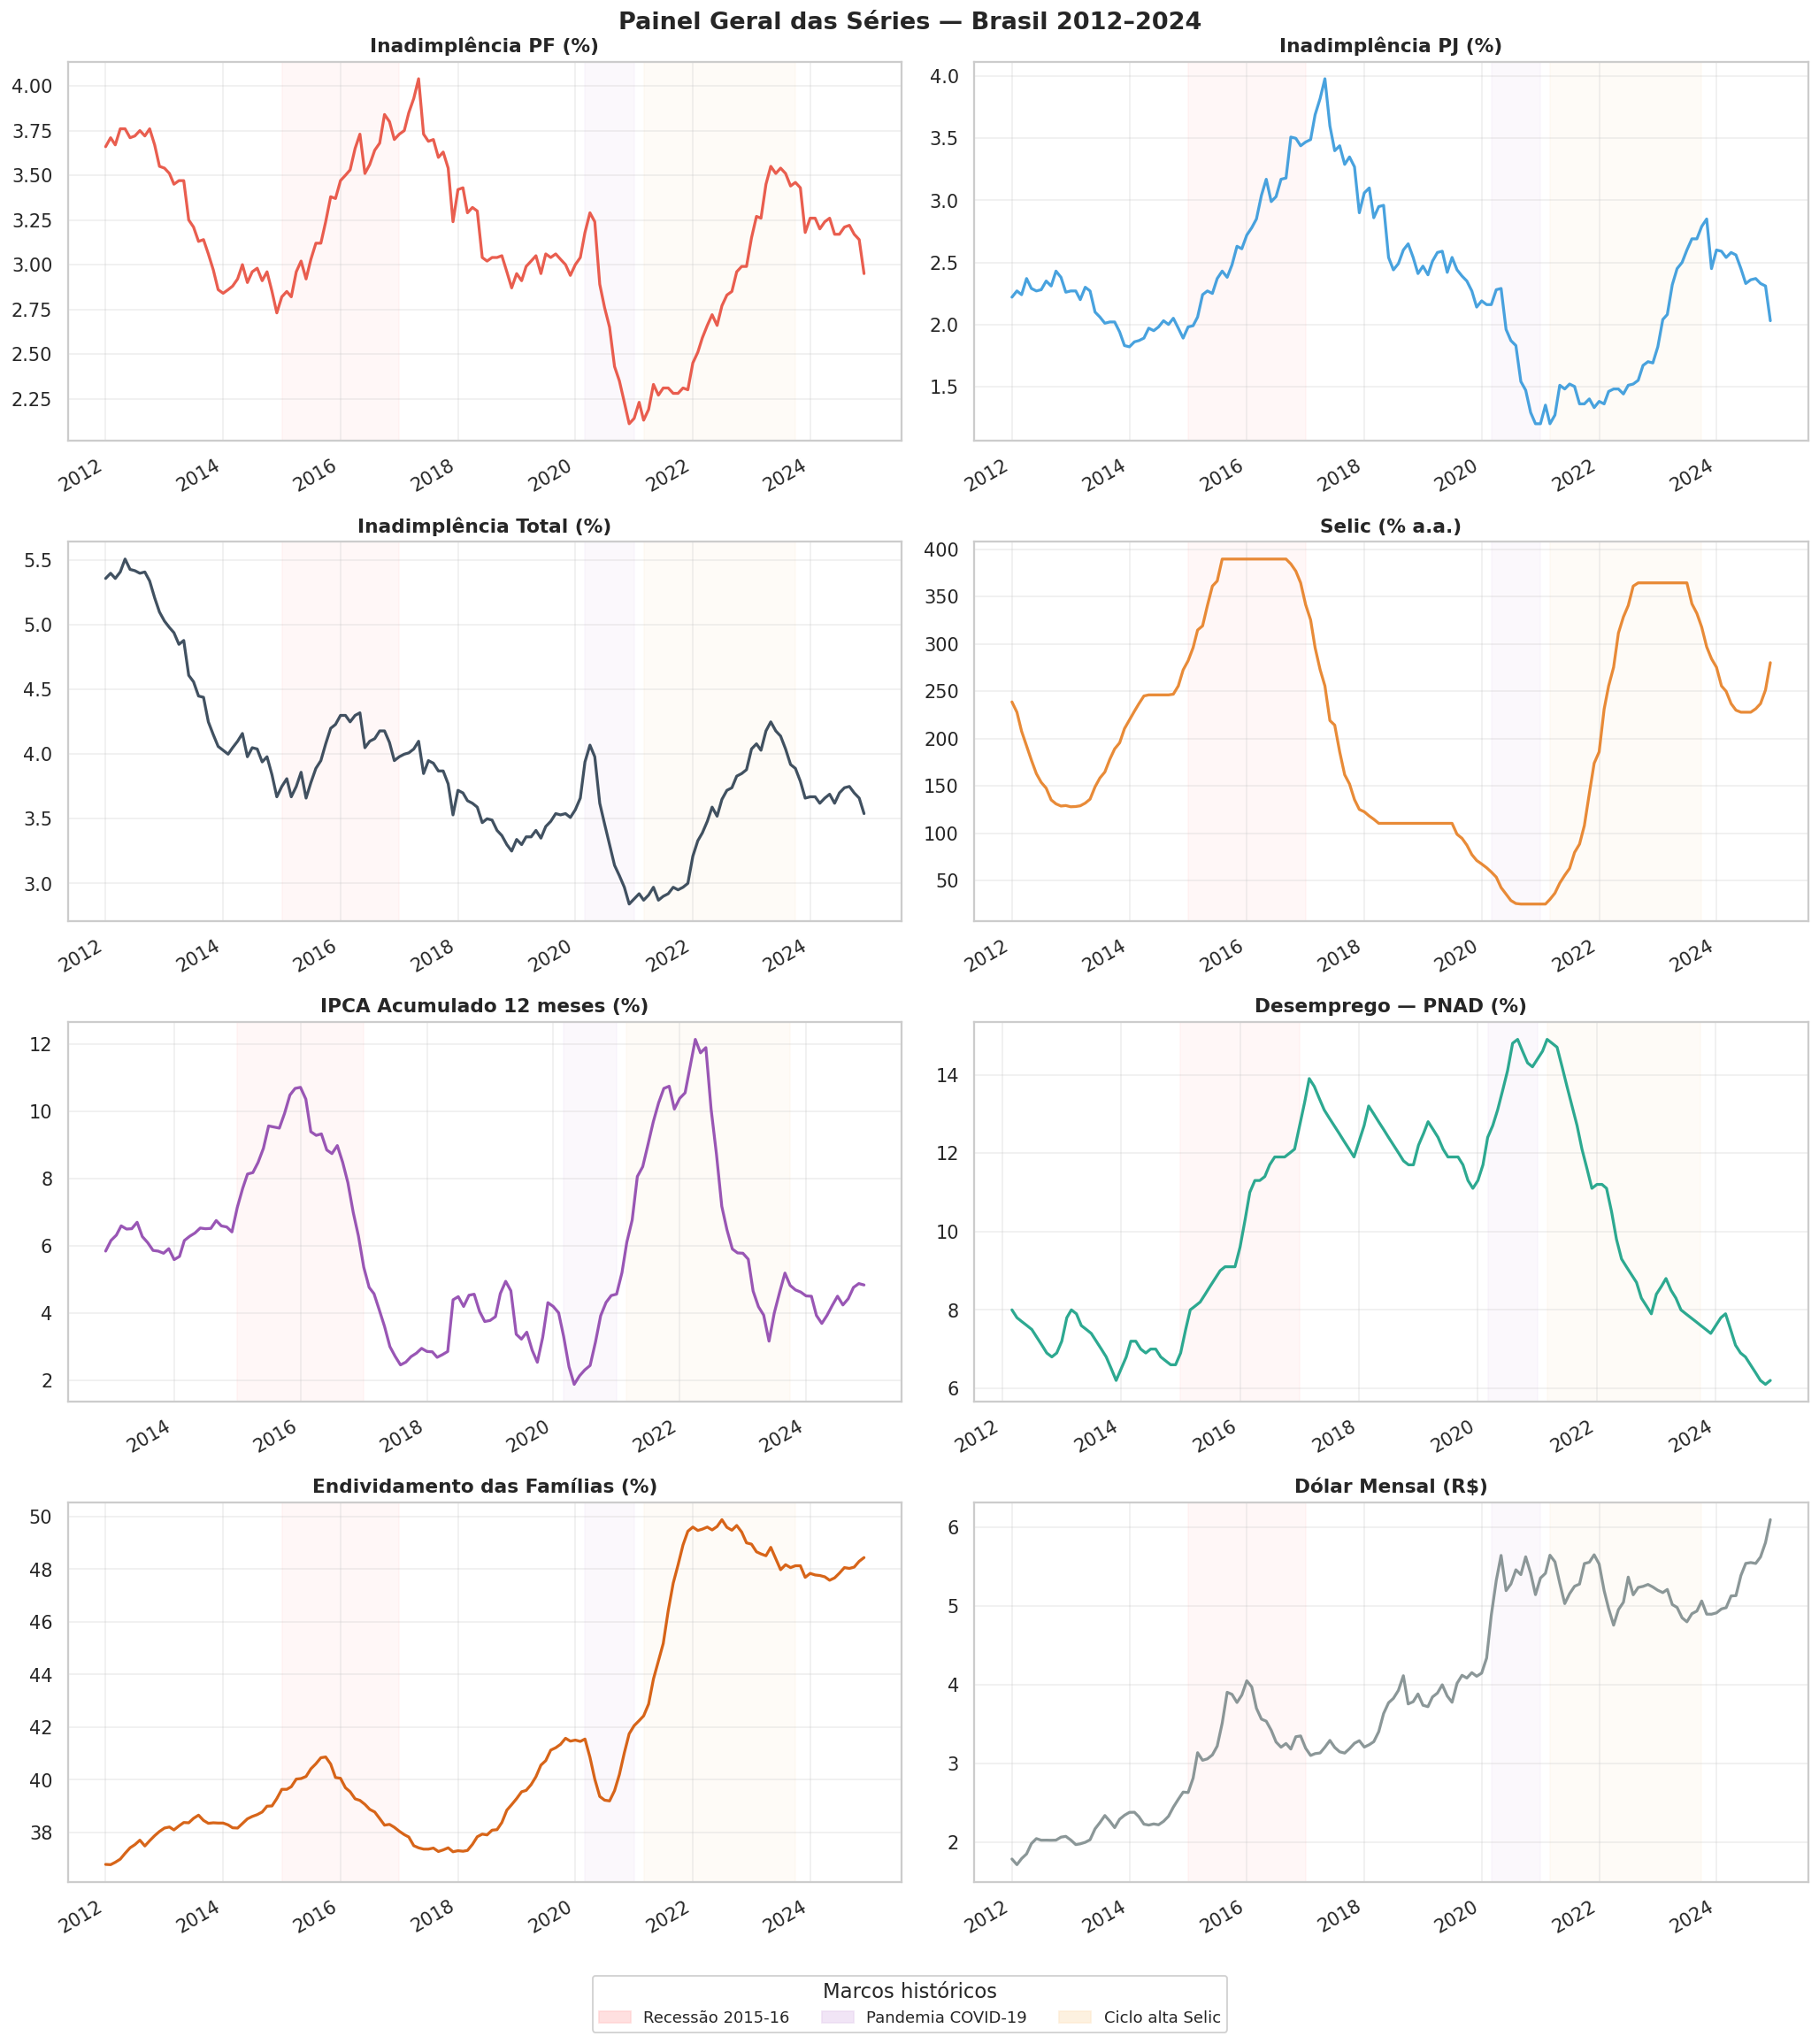

In [5]:
# ============================================================
# PAINEL GERAL — todas as séries disponíveis
# ============================================================
series_plot_config = [
    ('inad_pf',          'Inadimplência PF (%)',           '#e74c3c'),
    ('inad_pj',          'Inadimplência PJ (%)',           '#3498db'),
    ('inad_total',       'Inadimplência Total (%)',        '#2c3e50'),
    (SELIC_COL,           SELIC_LABEL,                       '#e67e22'),
    ('ipca_acum12',      'IPCA Acumulado 12 meses (%)',    '#8e44ad'),
    ('desemprego',       'Desemprego — PNAD (%)',          '#16a085'),
    ('endividamento_fam','Endividamento das Famílias (%)', '#d35400'),
    (DOLAR_COL or '',    'Dólar Mensal (R$)',              '#7f8c8d'),
]

# Filtrar só séries disponíveis
series_disponiveis = [(col, tit, cor) for col, tit, cor in series_plot_config
                      if col and col in df.columns]

n = len(series_disponiveis)
ncols = 2
nrows = (n + 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4.5))
axes_flat = axes.flat if hasattr(axes, 'flat') else [axes]
fig.suptitle('Painel Geral das Séries — Brasil 2012–2024',
             fontsize=15, fontweight='bold')

marcos_hist = [
    ('2015-01-01','2016-12-31','#ffcccc','Recessão 2015-16'),
    ('2020-03-01','2020-12-31','#e8d5f0','Pandemia'),
    ('2021-03-01','2023-09-30','#fde8cc','Alta Selic'),
]

for ax, (col, titulo, cor) in zip(axes_flat, series_disponiveis):
    serie = df[col].dropna()
    ax.plot(serie.index, serie.values, color=cor, linewidth=1.8, alpha=0.9)
    for ini, fim, c_f, _ in marcos_hist:
        ax.axvspan(pd.Timestamp(ini), pd.Timestamp(fim), alpha=0.15, color=c_f, zorder=0)
    ax.set_title(titulo)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax.grid(alpha=0.3)

# Esconder eixos vazios
for ax in list(axes_flat)[len(series_disponiveis):]:
    ax.set_visible(False)

legend_patches = [
    mpatches.Patch(color='#ffcccc', alpha=0.6, label='Recessão 2015-16'),
    mpatches.Patch(color='#e8d5f0', alpha=0.6, label='Pandemia COVID-19'),
    mpatches.Patch(color='#fde8cc', alpha=0.6, label='Ciclo alta Selic'),
]
fig.legend(handles=legend_patches, loc='lower center',
           ncol=3, fontsize=10, bbox_to_anchor=(0.5, 0.0),
           framealpha=0.9, title='Marcos históricos')

plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig('fig_b01_painel_geral.png', bbox_inches='tight')
plt.show()


---
## 3. Análise 1 — PF vs. PJ: Comportamentos Distintos <a id='3'></a>

> **Pergunta:** Pessoas físicas e jurídicas seguem o mesmo padrão de inadimplência  
> ou respondem diferentemente aos choques econômicos?

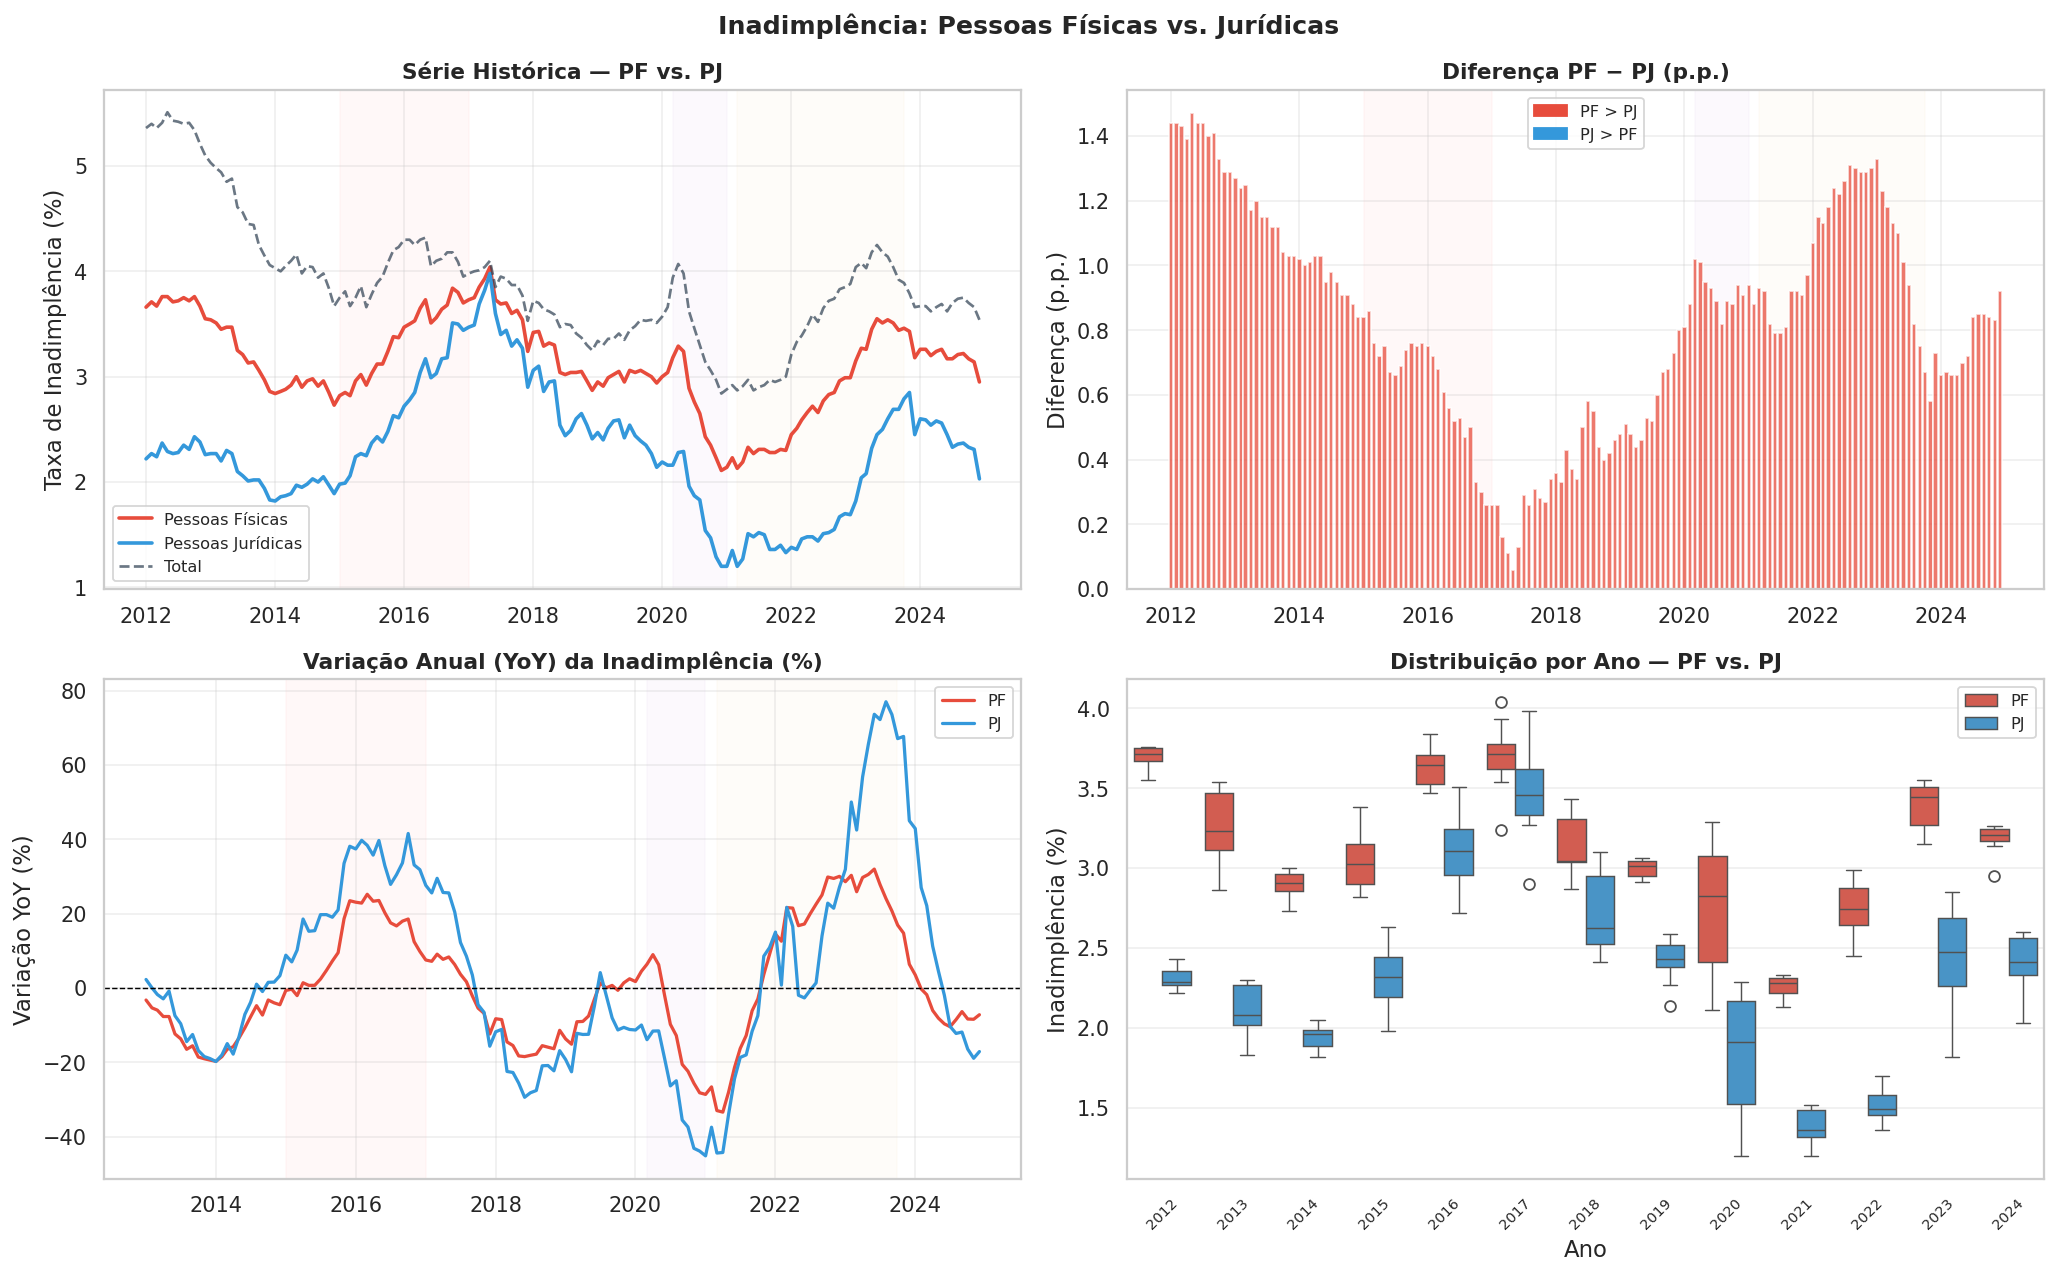

=== Médias por período ===
  Pré-recessão (2012-2014): PF=3.29% | PJ=2.12% | Total=4.65%
  Recessão (2015-2016): PF=3.34% | PJ=2.71% | Total=4.03%
  Recuperação (2017-2019): PF=3.28% | PJ=2.87% | Total=3.61%
  Pandemia (2020): PF=2.76% | PJ=1.85% | Total=3.47%
  Pós-pandemia (2021-2022): PF=2.50% | PJ=1.45% | Total=3.26%
  Recente (2023-2024): PF=3.29% | PJ=2.43% | Total=3.84%


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Inadimplência: Pessoas Físicas vs. Jurídicas',
             fontsize=14, fontweight='bold')

# Marcos
def add_marcos(ax):
    ax.axvspan(pd.Timestamp('2015-01-01'),pd.Timestamp('2016-12-31'),
               alpha=0.12, color='#ffcccc', zorder=0)
    ax.axvspan(pd.Timestamp('2020-03-01'),pd.Timestamp('2020-12-31'),
               alpha=0.12, color='#e8d5f0', zorder=0)
    ax.axvspan(pd.Timestamp('2021-03-01'),pd.Timestamp('2023-09-30'),
               alpha=0.10, color='#fde8cc', zorder=0)

# --- Painel 1: série temporal PF vs PJ ---
ax = axes[0,0]
ax.plot(df.index, df['inad_pf'], color='#e74c3c', lw=2, label='Pessoas Físicas')
ax.plot(df.index, df['inad_pj'], color='#3498db', lw=2, label='Pessoas Jurídicas')
ax.plot(df.index, df['inad_total'], color='#2c3e50', lw=1.5,
        linestyle='--', label='Total', alpha=0.7)
add_marcos(ax)
ax.set_title('Série Histórica — PF vs. PJ')
ax.set_ylabel('Taxa de Inadimplência (%)')
ax.legend(fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(alpha=0.3)

# --- Painel 2: diferença PF - PJ ---
ax2 = axes[0,1]
diff = df['inad_pf'] - df['inad_pj']
cores_diff = ['#e74c3c' if v >= 0 else '#3498db' for v in diff.dropna()]
ax2.bar(diff.dropna().index, diff.dropna().values,
        color=cores_diff, alpha=0.75, width=25)
ax2.axhline(0, color='black', linewidth=1)
add_marcos(ax2)
ax2.set_title('Diferença PF − PJ (p.p.)')
ax2.set_ylabel('Diferença (p.p.)')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax2.grid(alpha=0.3)
pf_patch = mpatches.Patch(color='#e74c3c', label='PF > PJ')
pj_patch = mpatches.Patch(color='#3498db', label='PJ > PF')
ax2.legend(handles=[pf_patch, pj_patch], fontsize=9)

# --- Painel 3: variação YoY ---
ax3 = axes[1,0]
df['inad_pf_yoy']  = df['inad_pf'].pct_change(12) * 100
df['inad_pj_yoy']  = df['inad_pj'].pct_change(12) * 100
ax3.plot(df.index, df['inad_pf_yoy'], color='#e74c3c', lw=1.8, label='PF')
ax3.plot(df.index, df['inad_pj_yoy'], color='#3498db', lw=1.8, label='PJ')
ax3.axhline(0, color='black', linewidth=0.8, linestyle='--')
add_marcos(ax3)
ax3.set_title('Variação Anual (YoY) da Inadimplência (%)')
ax3.set_ylabel('Variação YoY (%)')
ax3.legend(fontsize=9)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax3.grid(alpha=0.3)

# --- Painel 4: boxplot por ano ---
ax4 = axes[1,1]
df_box = df[['inad_pf','inad_pj']].copy()
df_box['ano'] = df_box.index.year
df_melt = df_box.melt(id_vars='ano', var_name='Tipo',
                       value_name='Inadimplência (%)')
df_melt['Tipo'] = df_melt['Tipo'].map({'inad_pf':'PF','inad_pj':'PJ'})
sns.boxplot(data=df_melt, x='ano', y='Inadimplência (%)',
            hue='Tipo', ax=ax4,
            palette={'PF':'#e74c3c','PJ':'#3498db'}, linewidth=0.8)
ax4.set_title('Distribuição por Ano — PF vs. PJ')
ax4.set_xlabel('Ano')
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45, fontsize=8)
ax4.legend(fontsize=9)
ax4.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('fig_b02_pf_vs_pj.png', bbox_inches='tight')
plt.show()

# Estatísticas
print('=== Médias por período ===')
periodos = {
    'Pré-recessão (2012-2014)':  ('2012-01','2014-12'),
    'Recessão (2015-2016)':       ('2015-01','2016-12'),
    'Recuperação (2017-2019)':    ('2017-01','2019-12'),
    'Pandemia (2020)':            ('2020-01','2020-12'),
    'Pós-pandemia (2021-2022)':   ('2021-01','2022-12'),
    'Recente (2023-2024)':        ('2023-01','2024-12'),
}
for periodo, (ini, fim) in periodos.items():
    sub = df.loc[ini:fim,['inad_pf','inad_pj','inad_total']]
    print(f'  {periodo}: PF={sub.inad_pf.mean():.2f}% | PJ={sub.inad_pj.mean():.2f}% | Total={sub.inad_total.mean():.2f}%')

---
## 4. Análise 2 — Decomposição por Modalidade de Crédito <a id='4'></a>

> **Pergunta:** Qual modalidade de crédito de PF concentra mais inadimplência?  
> Cartão, crédito pessoal, veículos ou habitação seguem trajetórias distintas?

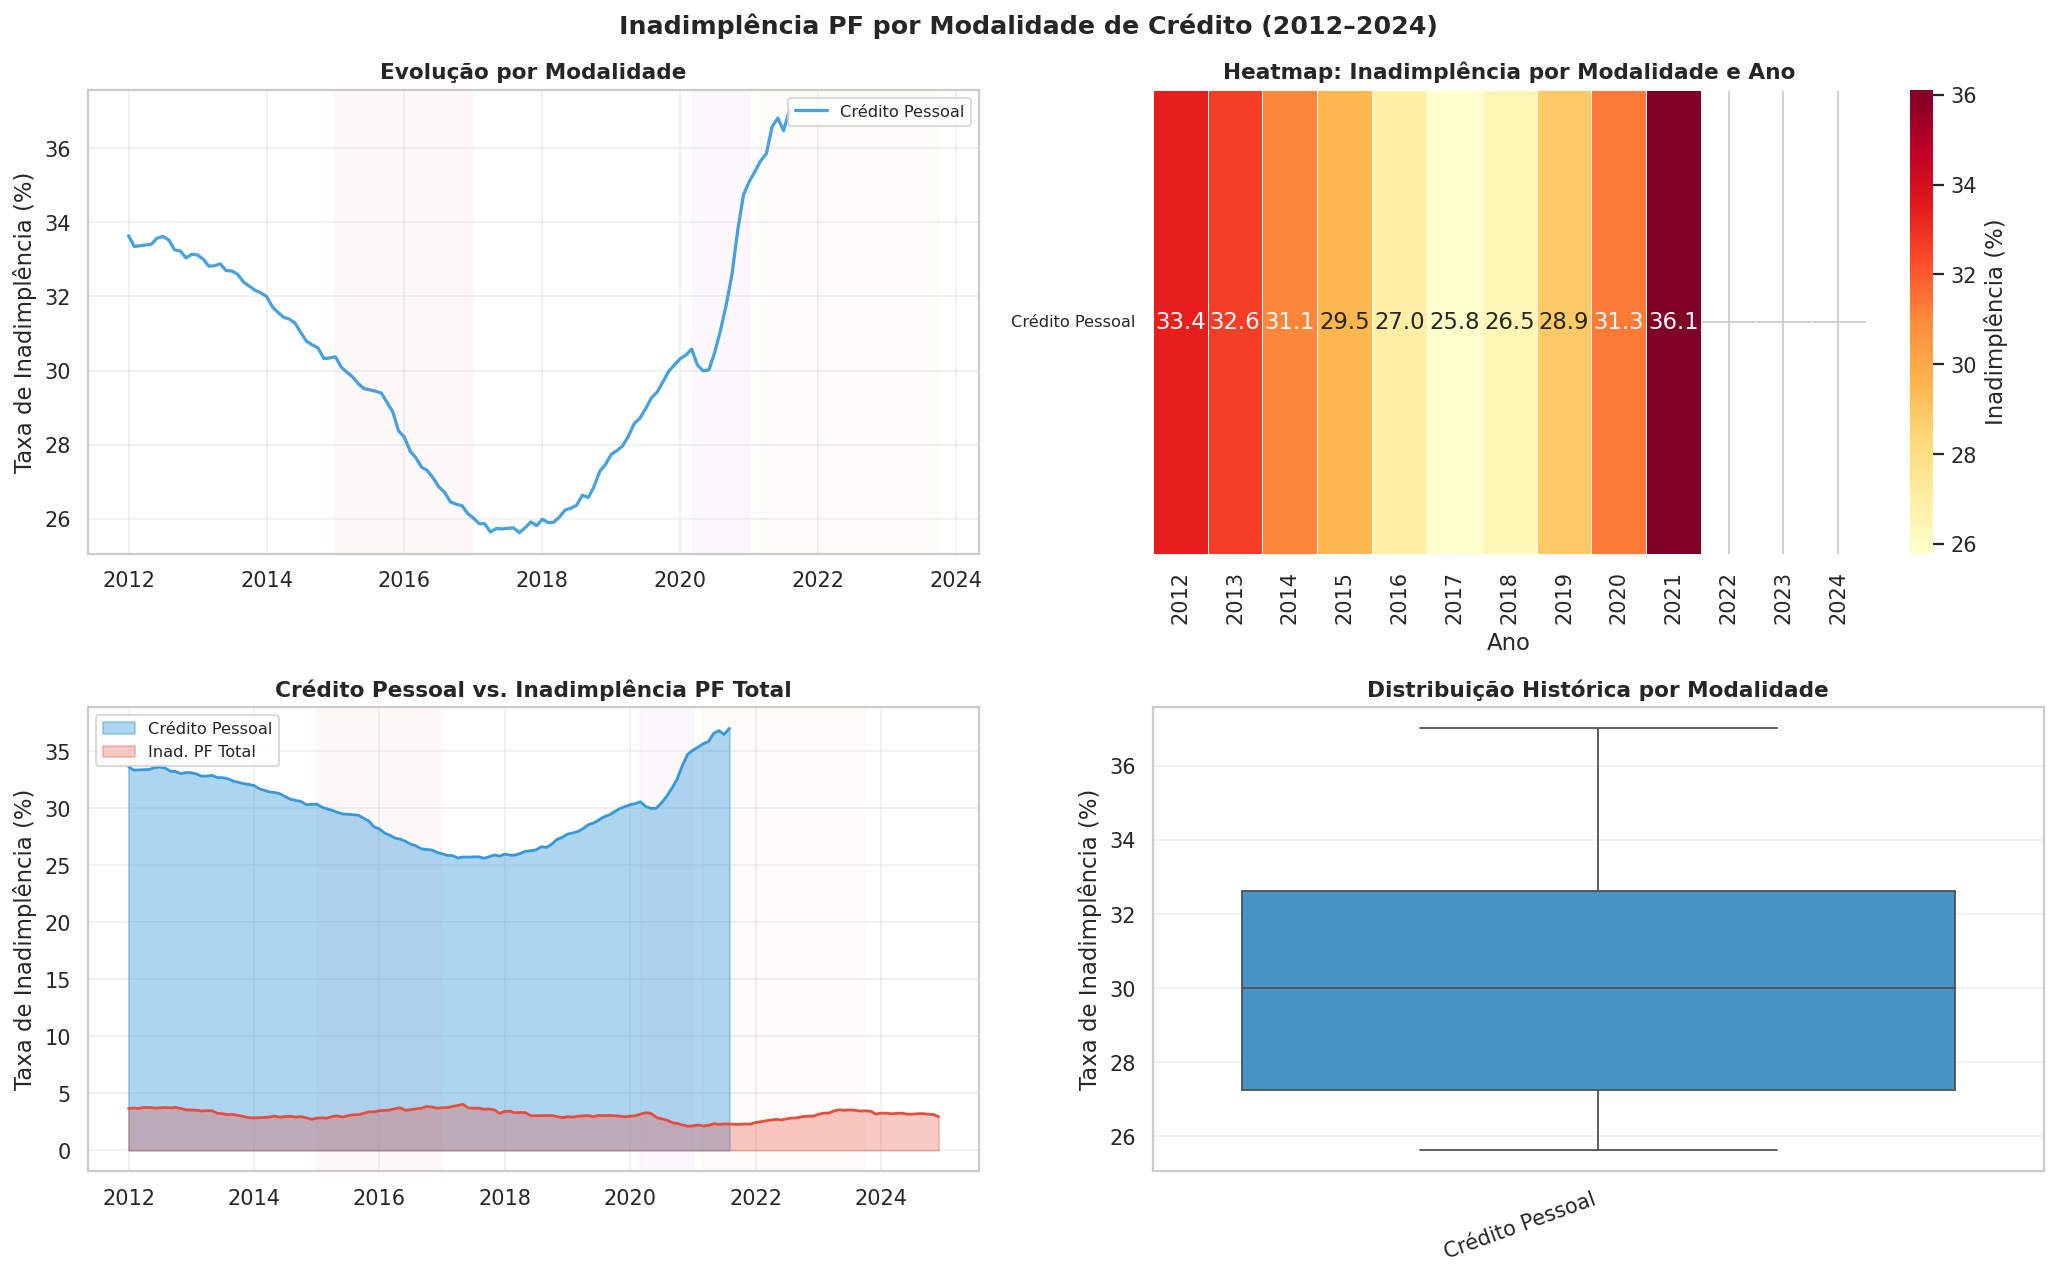

In [7]:
modalidades = {
    'inad_cartao_pf':   ('Cartão de Crédito',       '#e74c3c'),
    'inad_credpes_pf':  ('Crédito Pessoal',          '#3498db'),
    'inad_veiculos_pf': ('Financiamento Veículos',   '#2ecc71'),
    'inad_habita_pf':   ('Crédito Habitacional',     '#f39c12'),
}

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Inadimplência PF por Modalidade de Crédito (2012–2024)',
             fontsize=14, fontweight='bold')

# --- Painel 1: séries todas juntas ---
ax = axes[0,0]
for col, (label, cor) in modalidades.items():
    if col in df.columns:
        ax.plot(df.index, df[col], label=label, color=cor, lw=1.8, alpha=0.9)
add_marcos(ax)
ax.set_title('Evolução por Modalidade')
ax.set_ylabel('Taxa de Inadimplência (%)')
ax.legend(fontsize=9, loc='upper right')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.grid(alpha=0.3)

# --- Painel 2: radar / heatmap por ano ---
ax2 = axes[0,1]
cols_mod = [c for c in modalidades if c in df.columns]
labels_mod = [modalidades[c][0] for c in cols_mod]
df_heat = df[cols_mod].copy()
df_heat.columns = labels_mod
df_heat['ano'] = df_heat.index.year
df_heat_yr = df_heat.groupby('ano').mean()
sns.heatmap(df_heat_yr.T, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=ax2, linewidths=0.3,
            cbar_kws={'label': 'Inadimplência (%)'})
ax2.set_title('Heatmap: Inadimplência por Modalidade e Ano')
ax2.set_xlabel('Ano')
ax2.set_yticklabels(ax2.get_yticklabels(), rotation=0, fontsize=9)

# --- Painel 3: variação da inadimplência — cartão vs crédito pessoal ---
ax3 = axes[1,0]
if 'inad_credpes_pf' in df.columns:
    # Crédito pessoal vs inadimplência total PF
    ax3.fill_between(df.index, df['inad_credpes_pf'].dropna().reindex(df.index),
                     alpha=0.4, color='#3498db', label='Crédito Pessoal')
    ax3.fill_between(df.index, df['inad_pf'],
                     alpha=0.3, color='#e74c3c', label='Inad. PF Total')
    ax3.plot(df.index, df['inad_credpes_pf'], color='#3498db', lw=1.5)
    ax3.plot(df.index, df['inad_pf'], color='#e74c3c', lw=1.5)
add_marcos(ax3)
ax3.set_title('Crédito Pessoal vs. Inadimplência PF Total')
ax3.set_ylabel('Taxa de Inadimplência (%)')
ax3.legend(fontsize=9)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax3.grid(alpha=0.3)

# --- Painel 4: boxplot por modalidade ---
ax4 = axes[1,1]
df_box_mod = df[cols_mod].dropna()
df_box_mod.columns = labels_mod
sns.boxplot(data=df_box_mod, ax=ax4,
            palette=[modalidades[c][1] for c in cols_mod])
ax4.set_title('Distribuição Histórica por Modalidade')
ax4.set_ylabel('Taxa de Inadimplência (%)')
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=20, ha='right')
ax4.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('fig_b03_modalidades.png', bbox_inches='tight')
plt.show()

---
## 5. Análise 3 — Ciclos Econômicos e Choques <a id='5'></a>

> Identificar os principais **pontos de inflexão** na série de inadimplência  
> e associá-los a eventos macroeconômicos.

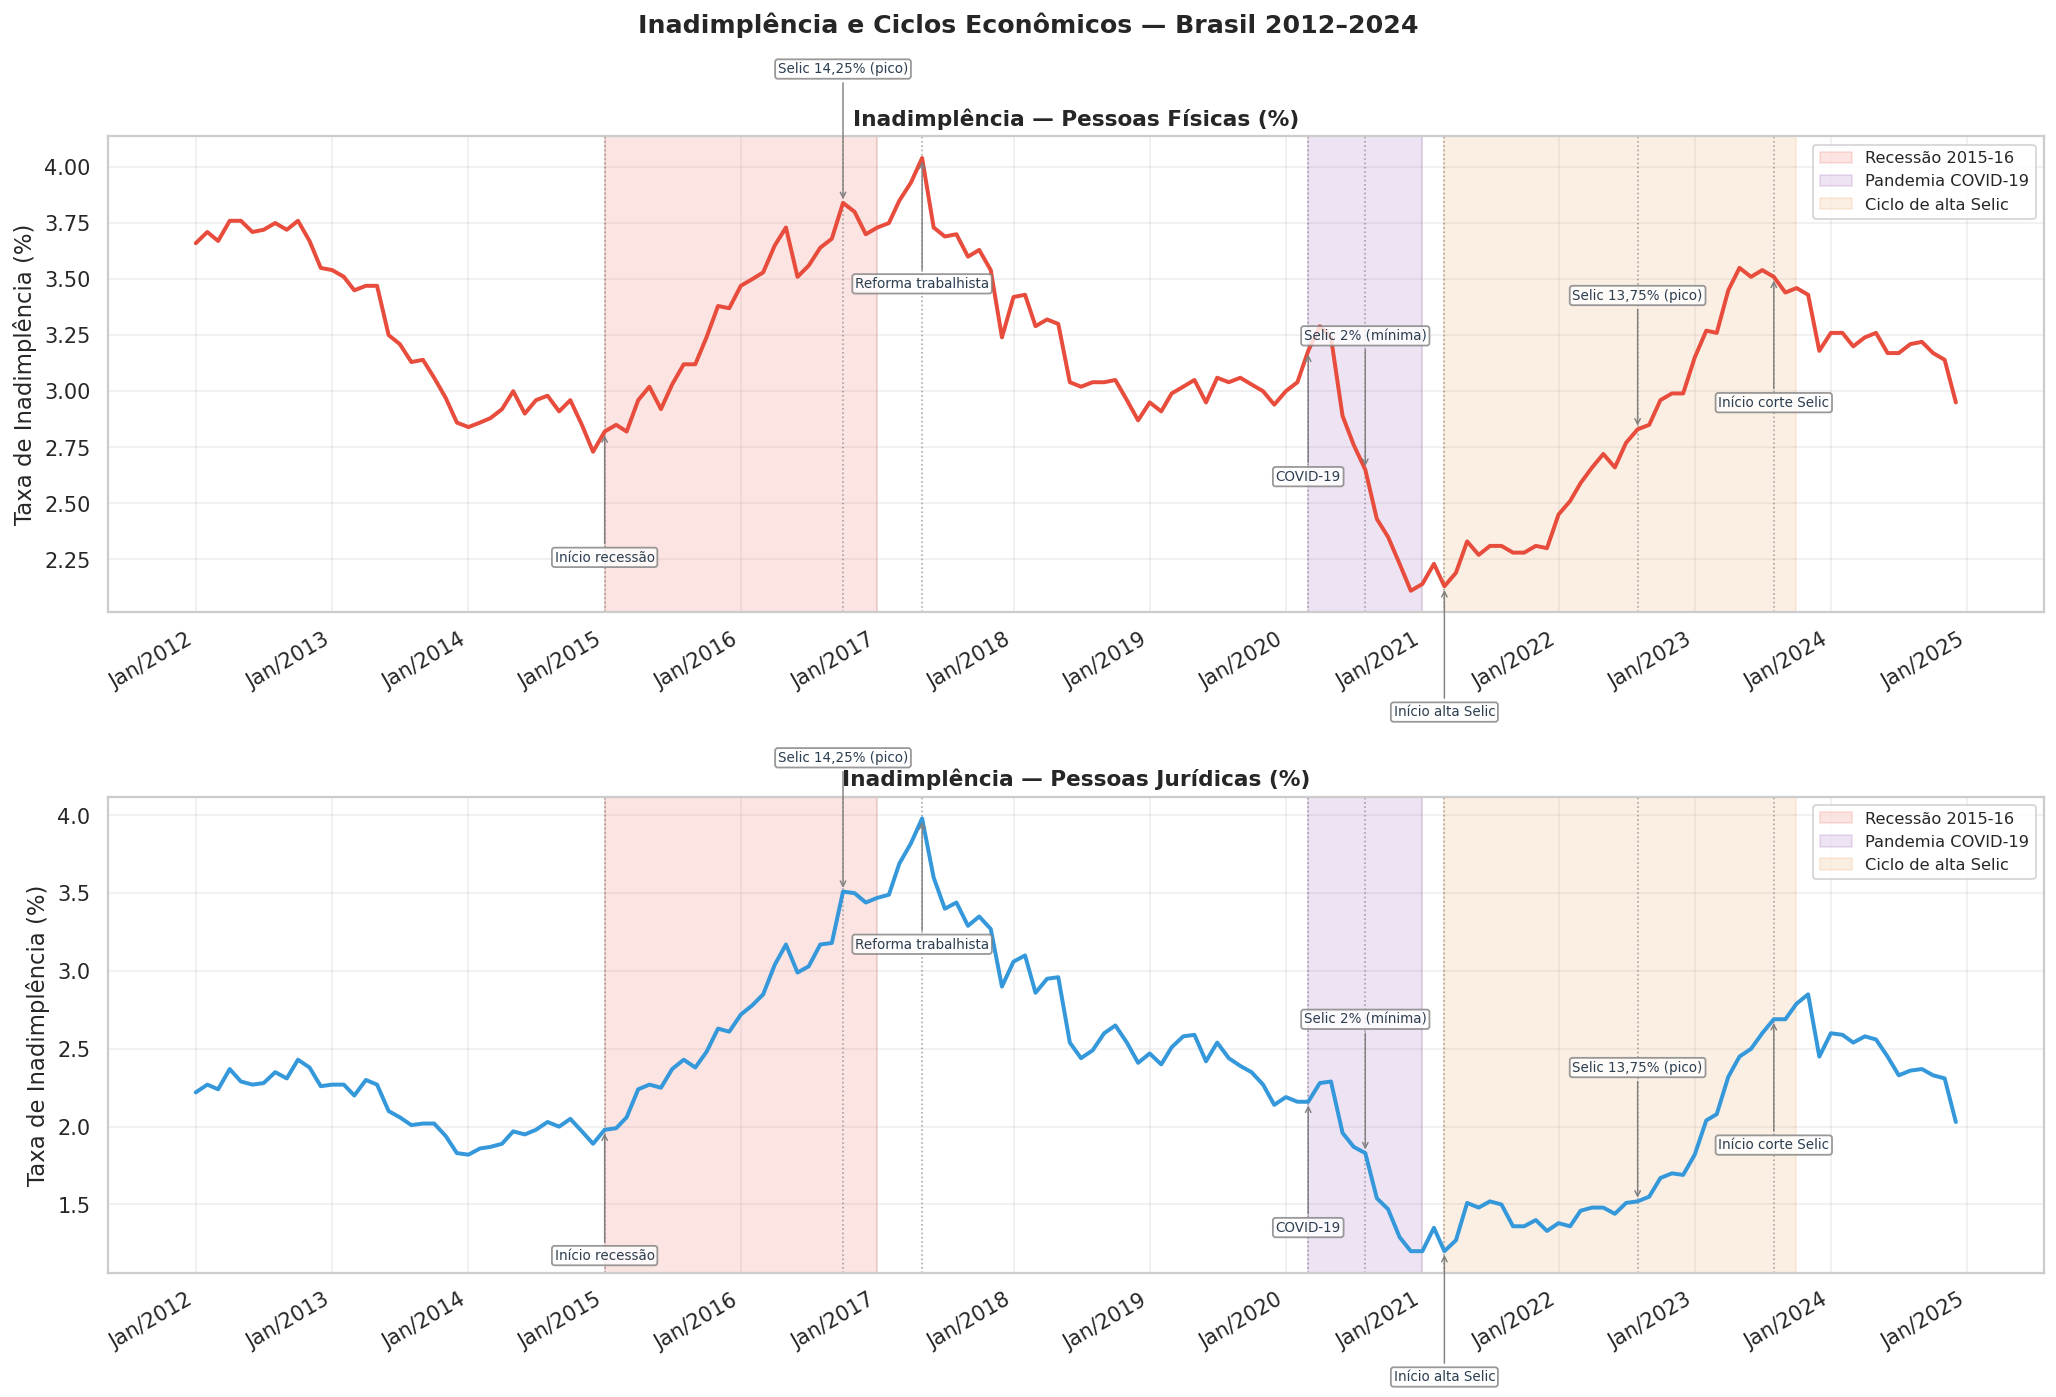

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(16, 11))
fig.suptitle('Inadimplência e Ciclos Econômicos — Brasil 2012–2024',
             fontsize=14, fontweight='bold')

eventos = [
    ('2015-01', 'Início recessão',       'top',    -0.3),
    ('2016-10', 'Selic 14,25% (pico)',   'bottom',  0.3),
    ('2017-05', 'Reforma trabalhista',   'top',    -0.3),
    ('2020-03', 'COVID-19',              'top',    -0.3),
    ('2020-08', 'Selic 2% (mínima)',     'bottom',  0.3),
    ('2021-03', 'Início alta Selic',     'top',    -0.3),
    ('2022-08', 'Selic 13,75% (pico)',   'bottom',  0.3),
    ('2023-08', 'Início corte Selic',    'top',    -0.3),
]

for ax, (col, titulo, cor) in zip(axes,
    [('inad_pf','Inadimplência — Pessoas Físicas (%)','#e74c3c'),
     ('inad_pj','Inadimplência — Pessoas Jurídicas (%)','#3498db')]):

    serie = df[col].dropna()
    ax.plot(serie.index, serie.values, color=cor, lw=2.2, zorder=3)

    # Sombreamento dos ciclos
    ax.axvspan(pd.Timestamp('2015-01-01'),pd.Timestamp('2016-12-31'),
               alpha=0.15, color='#e74c3c', label='Recessão 2015-16')
    ax.axvspan(pd.Timestamp('2020-03-01'),pd.Timestamp('2020-12-31'),
               alpha=0.15, color='#8e44ad', label='Pandemia COVID-19')
    ax.axvspan(pd.Timestamp('2021-03-01'),pd.Timestamp('2023-09-30'),
               alpha=0.12, color='#e67e22', label='Ciclo de alta Selic')

    # Anotações de eventos
    y_min, y_max = serie.min(), serie.max()
    y_range = y_max - y_min
    for data, label, pos, offset in eventos:
        try:
            val = serie.asof(pd.Timestamp(data))
            if pd.isna(val): continue
            ax.axvline(pd.Timestamp(data), color='gray',
                       linestyle=':', linewidth=0.9, alpha=0.7, zorder=2)
            y_ann = val + offset * y_range
            ax.annotate(label,
                xy=(pd.Timestamp(data), val),
                xytext=(pd.Timestamp(data), y_ann),
                fontsize=7.5, ha='center', color='#2c3e50',
                arrowprops=dict(arrowstyle='->', color='gray', lw=0.8),
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                          alpha=0.8, edgecolor='gray'))
        except: pass

    ax.set_title(titulo)
    ax.set_ylabel('Taxa de Inadimplência (%)')
    ax.legend(fontsize=9, loc='upper right')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b/%Y'))
    ax.xaxis.set_major_locator(mdates.YearLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig_b04_ciclos.png', bbox_inches='tight')
plt.show()

---
## 6. Análise 4 — Correlação com Selic e IPCA <a id='6'></a>

> **Hipótese:** Juros altos aumentam o custo da dívida → maior inadimplência  
> com **defasagem** de alguns meses (famílias não ficam inadimplentes no mesmo mês  
> em que os juros sobem).

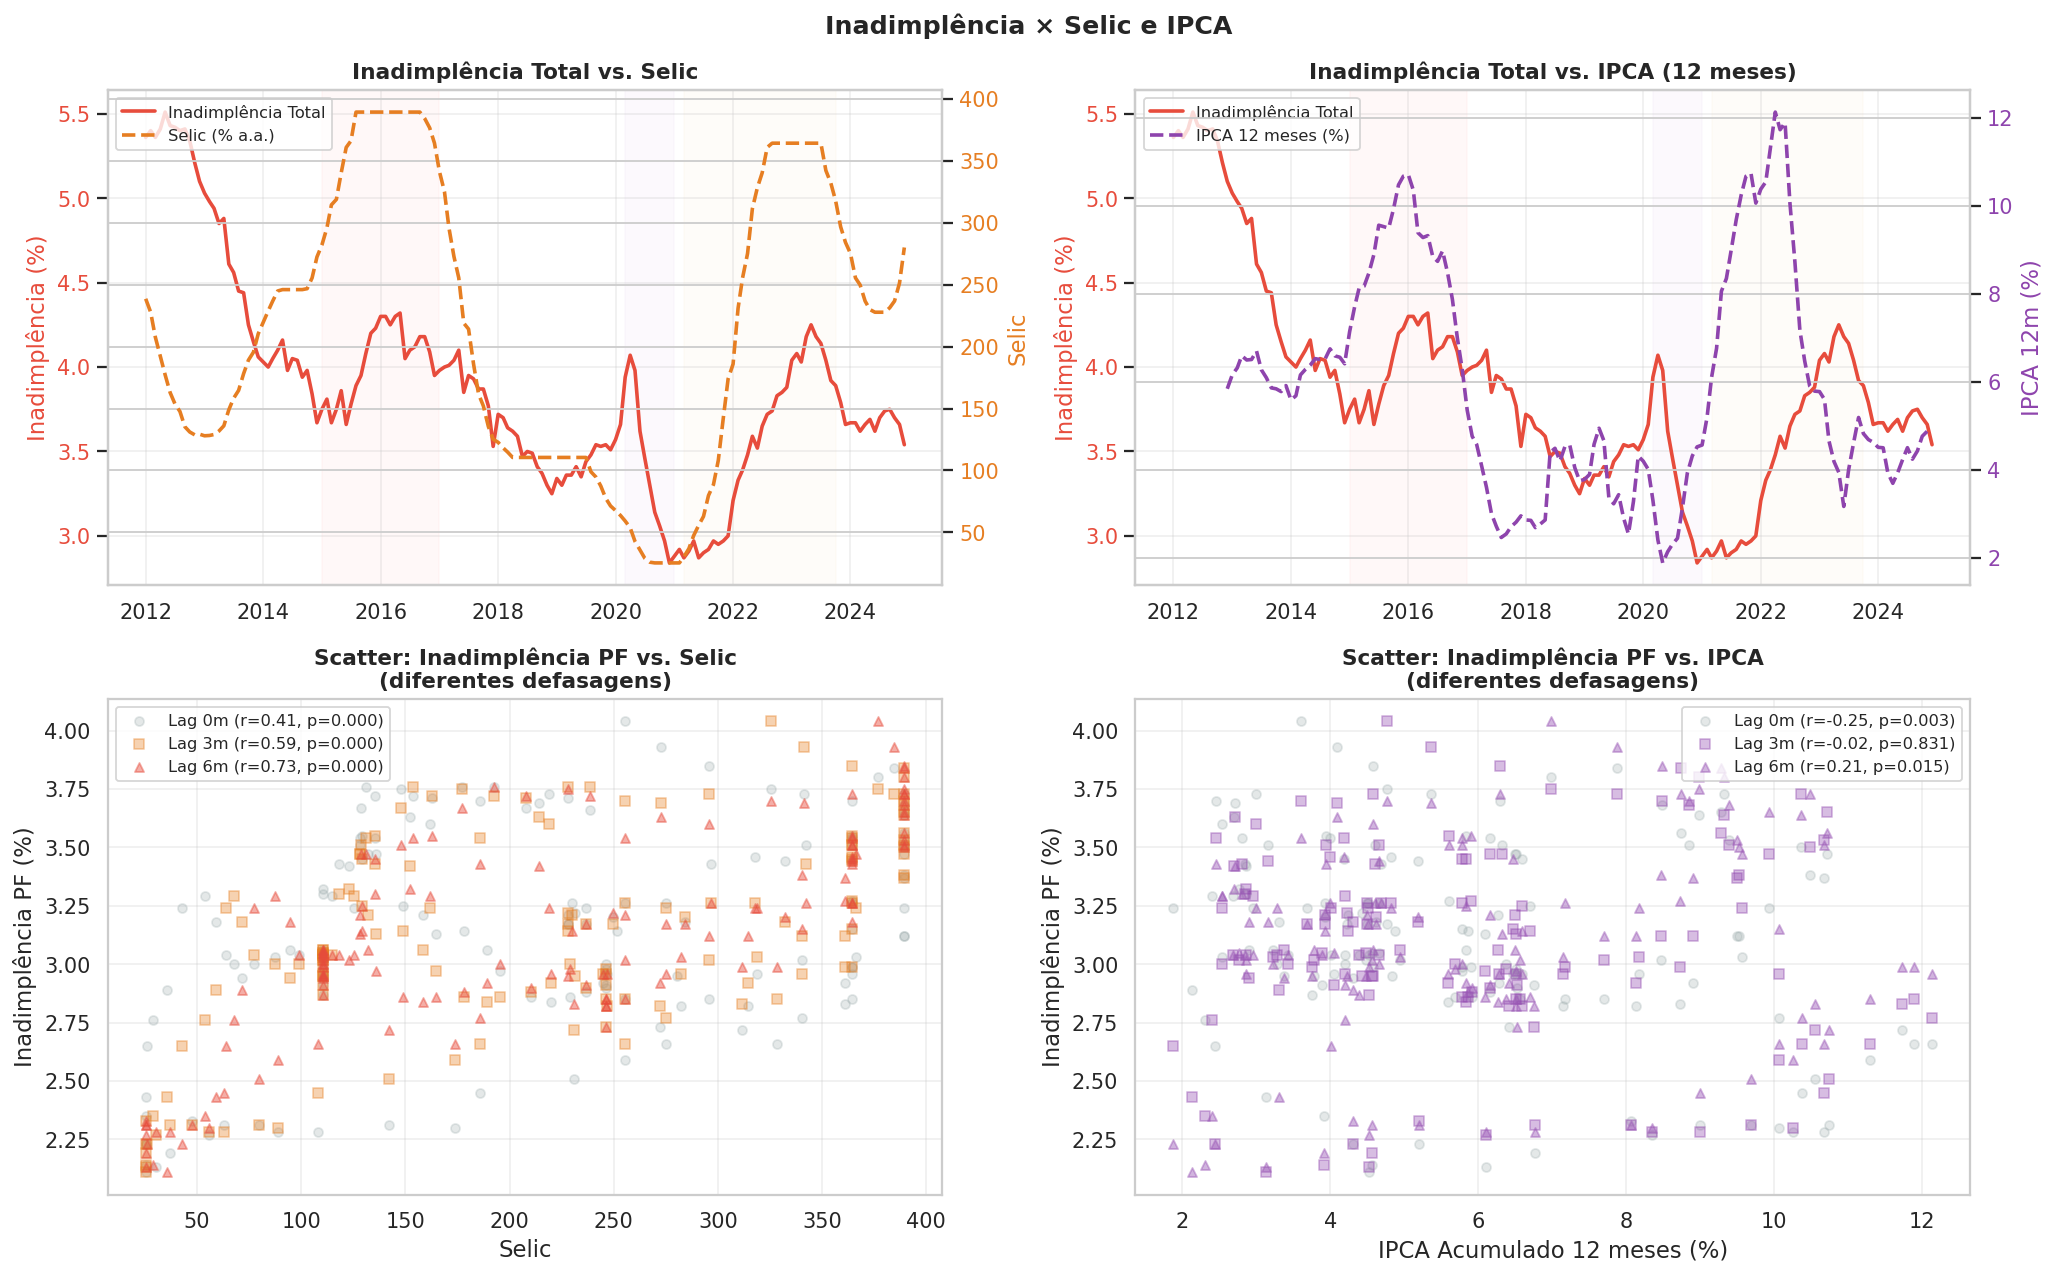

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Inadimplência × Selic e IPCA', fontsize=14, fontweight='bold')

# --- Painel 1: inad_total + selic ---
ax = axes[0,0]
ax2_twin = ax.twinx()
ax.plot(df.index, df['inad_total'], color='#e74c3c', lw=2, label='Inadimplência Total')
if SELIC_COL in df.columns:
    ax2_twin.plot(df.index, df[SELIC_COL], color='#e67e22',
                  lw=2, linestyle='--',
                  label=f'Selic ({"% a.a." if SELIC_COL=="selic_anual" else "% a.m."})')
ax.set_ylabel('Inadimplência (%)', color='#e74c3c')
ax2_twin.set_ylabel('Selic', color='#e67e22')
ax.tick_params(axis='y', labelcolor='#e74c3c')
ax2_twin.tick_params(axis='y', labelcolor='#e67e22')
ax.set_title('Inadimplência Total vs. Selic')
l1, lb1 = ax.get_legend_handles_labels()
l2, lb2 = ax2_twin.get_legend_handles_labels()
ax.legend(l1+l2, lb1+lb2, fontsize=9, loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
add_marcos(ax); ax.grid(alpha=0.3)

# --- Painel 2: inad_total + ipca ---
ax3 = axes[0,1]
ax4_twin = ax3.twinx()
ax3.plot(df.index, df['inad_total'], color='#e74c3c', lw=2, label='Inadimplência Total')
ax4_twin.plot(df.index, df['ipca_acum12'], color='#8e44ad',
              lw=2, linestyle='--', label='IPCA 12 meses (%)')
ax3.set_ylabel('Inadimplência (%)', color='#e74c3c')
ax4_twin.set_ylabel('IPCA 12m (%)', color='#8e44ad')
ax3.tick_params(axis='y', labelcolor='#e74c3c')
ax4_twin.tick_params(axis='y', labelcolor='#8e44ad')
ax3.set_title('Inadimplência Total vs. IPCA (12 meses)')
l3, lb3 = ax3.get_legend_handles_labels()
l4, lb4 = ax4_twin.get_legend_handles_labels()
ax3.legend(l3+l4, lb3+lb4, fontsize=9, loc='upper left')
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
add_marcos(ax3); ax3.grid(alpha=0.3)

# --- Painel 3: scatter inad_pf vs selic ---
ax5 = axes[1,0]
if SELIC_COL in df.columns:
    for lag, marker, cor, alph in [(0,'o','#95a5a6',0.5),
                                    (3,'s','#e67e22',0.7),
                                    (6,'^','#e74c3c',0.9)]:
        x = df[SELIC_COL].shift(lag).dropna()
        y = df['inad_pf'].reindex(x.index).dropna()
        x = x.reindex(y.index)
        if len(x) < 10: continue
        r, p = pearsonr(x, y)
        ax5.scatter(x, y, alpha=alph*0.5, s=25, color=cor, marker=marker,
                    label=f'Lag {lag}m (r={r:.2f}, p={p:.3f})')
    ax5.set_xlabel('Selic')
    ax5.set_ylabel('Inadimplência PF (%)')
    ax5.set_title('Scatter: Inadimplência PF vs. Selic\n(diferentes defasagens)')
    ax5.legend(fontsize=9); ax5.grid(alpha=0.3)
else:
    ax5.text(0.5, 0.5, 'Selic não disponível\nVerifique a coleta de dados',
             ha='center', va='center', transform=ax5.transAxes,
             fontsize=11, color='gray')
    ax5.set_title('Scatter: Inadimplência PF vs. Selic')

# --- Painel 4: scatter inad_pf vs ipca ---
ax6 = axes[1,1]
for lag, marker, cor, alph in [(0,'o','#95a5a6',0.5),
                                 (3,'s','#8e44ad',0.7),
                                 (6,'^','#9b59b6',0.9)]:
    x = df['ipca_acum12'].shift(lag).dropna()
    y = df['inad_pf'].reindex(x.index).dropna()
    x = x.reindex(y.index)
    if len(x) < 10: continue
    r, p = pearsonr(x, y)
    ax6.scatter(x, y, alpha=alph*0.5, s=25, color=cor, marker=marker,
                label=f'Lag {lag}m (r={r:.2f}, p={p:.3f})')
ax6.set_xlabel('IPCA Acumulado 12 meses (%)')
ax6.set_ylabel('Inadimplência PF (%)')
ax6.set_title('Scatter: Inadimplência PF vs. IPCA\n(diferentes defasagens)')
ax6.legend(fontsize=9); ax6.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig_b05_selic_ipca.png', bbox_inches='tight')
plt.show()


---
## 7. Análise 5 — Correlação com Desemprego e PIB <a id='7'></a>

> **Hipótese:** Desemprego alto → queda de renda → inadimplência cresce.  
> PIB em queda → recessão → inadimplência cresce.

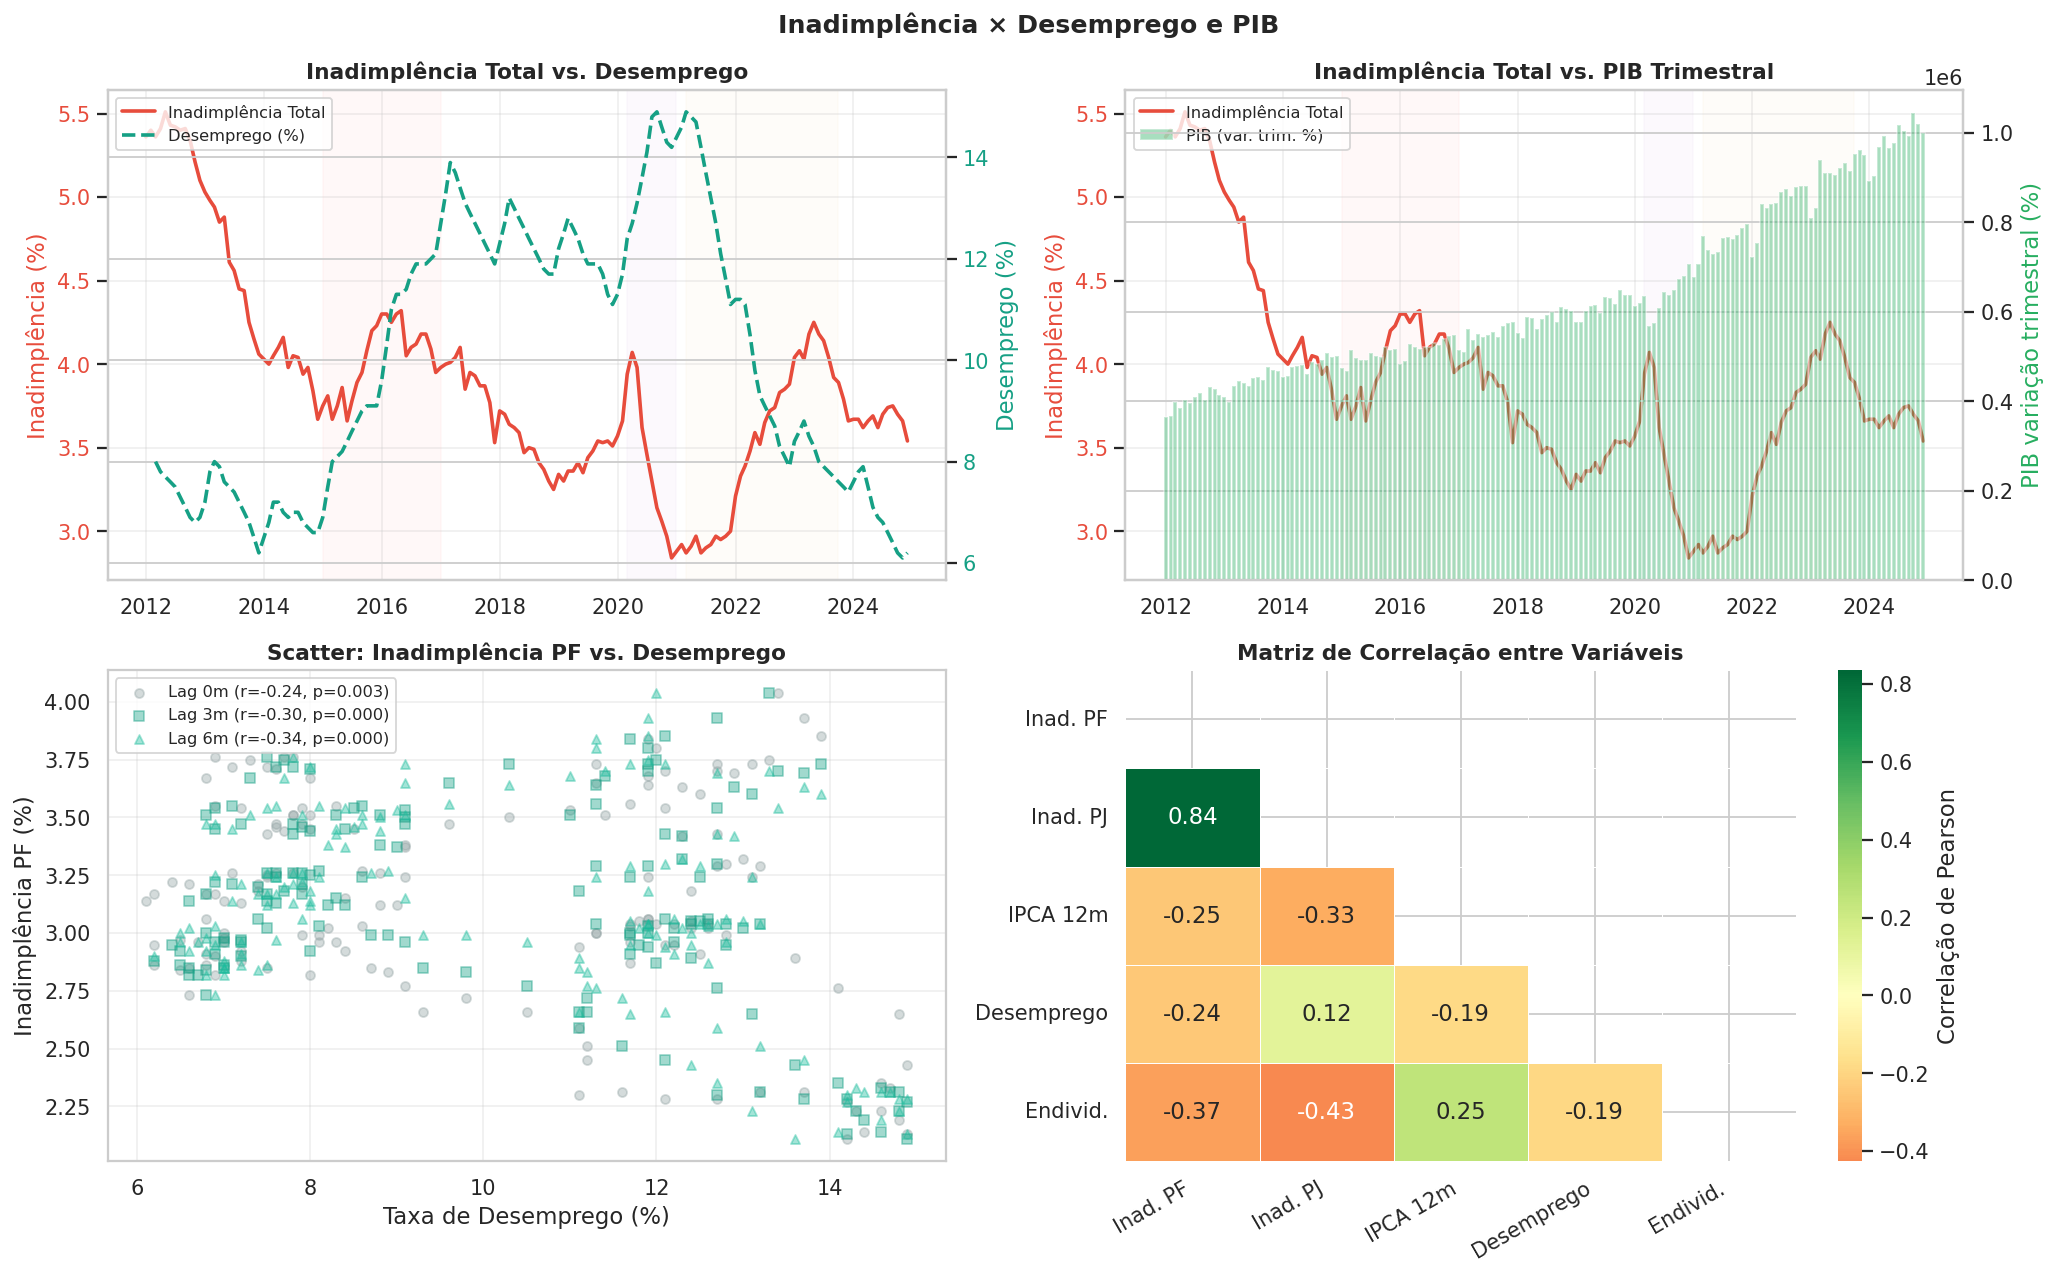

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Inadimplência × Desemprego e PIB', fontsize=14, fontweight='bold')

# --- Painel 1: inad_total + desemprego ---
ax = axes[0,0]
ax_t = ax.twinx()
ax.plot(df.index, df['inad_total'], color='#e74c3c', lw=2, label='Inadimplência Total')
ax_t.plot(df.index, df['desemprego'], color='#16a085',
          lw=2, linestyle='--', label='Desemprego (%)')
ax.set_ylabel('Inadimplência (%)', color='#e74c3c')
ax_t.set_ylabel('Desemprego (%)', color='#16a085')
ax.tick_params(axis='y', labelcolor='#e74c3c')
ax_t.tick_params(axis='y', labelcolor='#16a085')
ax.set_title('Inadimplência Total vs. Desemprego')
l1, lb1 = ax.get_legend_handles_labels()
l2, lb2 = ax_t.get_legend_handles_labels()
ax.legend(l1+l2, lb1+lb2, fontsize=9, loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
add_marcos(ax); ax.grid(alpha=0.3)

# --- Painel 2: inad_total + PIB trim ---
ax2 = axes[0,1]
if 'pib_var_trim' in df.columns:
    ax2_t = ax2.twinx()
    ax2.plot(df.index, df['inad_total'], color='#e74c3c', lw=2, label='Inadimplência Total')
    ax2_t.bar(df.index, df['pib_var_trim'],
              color=['#27ae60' if v >= 0 else '#e74c3c'
                     for v in df['pib_var_trim'].fillna(0)],
              alpha=0.4, width=25, label='PIB (var. trim. %)')
    ax2.set_ylabel('Inadimplência (%)', color='#e74c3c')
    ax2_t.set_ylabel('PIB variação trimestral (%)', color='#27ae60')
    ax2.tick_params(axis='y', labelcolor='#e74c3c')
    ax2.set_title('Inadimplência Total vs. PIB Trimestral')
    l3, lb3 = ax2.get_legend_handles_labels()
    l4, lb4 = ax2_t.get_legend_handles_labels()
    ax2.legend(l3+l4, lb3+lb4, fontsize=9, loc='upper left')
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    add_marcos(ax2); ax2.grid(alpha=0.3)
else:
    ax2.text(0.5,0.5,'PIB não disponível',ha='center',va='center',
             transform=ax2.transAxes, fontsize=11, color='gray')

# --- Painel 3: scatter inad_pf vs desemprego ---
ax3 = axes[1,0]
for lag, cor, marker in [(0,'#95a5a6','o'),(3,'#16a085','s'),(6,'#1abc9c','^')]:
    x = df['desemprego'].shift(lag).dropna()
    y = df['inad_pf'].reindex(x.index).dropna()
    x = x.reindex(y.index)
    r, p = pearsonr(x, y)
    ax3.scatter(x, y, alpha=0.4, s=25, color=cor, marker=marker,
                label=f'Lag {lag}m (r={r:.2f}, p={p:.3f})')
ax3.set_xlabel('Taxa de Desemprego (%)')
ax3.set_ylabel('Inadimplência PF (%)')
ax3.set_title('Scatter: Inadimplência PF vs. Desemprego')
ax3.legend(fontsize=9); ax3.grid(alpha=0.3)

# --- Painel 4: matriz de correlação ---
ax4 = axes[1,1]
cols_corr = ['inad_pf','inad_pj','selic_meta','ipca_acum12',
             'desemprego','endividamento_fam','dolar_ptax']
cols_corr = [c for c in cols_corr if c in df.columns]
labels_corr = {
    'inad_pf':'Inad. PF','inad_pj':'Inad. PJ',
    'selic_meta':'Selic','ipca_acum12':'IPCA 12m',
    'desemprego':'Desemprego','endividamento_fam':'Endivid.',
    'dolar_ptax':'Dólar'
}
corr_mat = df[cols_corr].corr()
corr_mat.index   = [labels_corr.get(c,c) for c in corr_mat.index]
corr_mat.columns = [labels_corr.get(c,c) for c in corr_mat.columns]
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, mask=mask, ax=ax4,
            linewidths=0.5, cbar_kws={'label':'Correlação de Pearson'})
ax4.set_title('Matriz de Correlação entre Variáveis')
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('fig_b06_desemprego_pib.png', bbox_inches='tight')
plt.show()

---
## 8. Análise 6 — Endividamento vs. Inadimplência <a id='8'></a>

> **Pergunta:** Endividamento alto necessariamente leva à inadimplência,  
> ou as famílias conseguem se manter adimplentes mesmo muito endividadas?

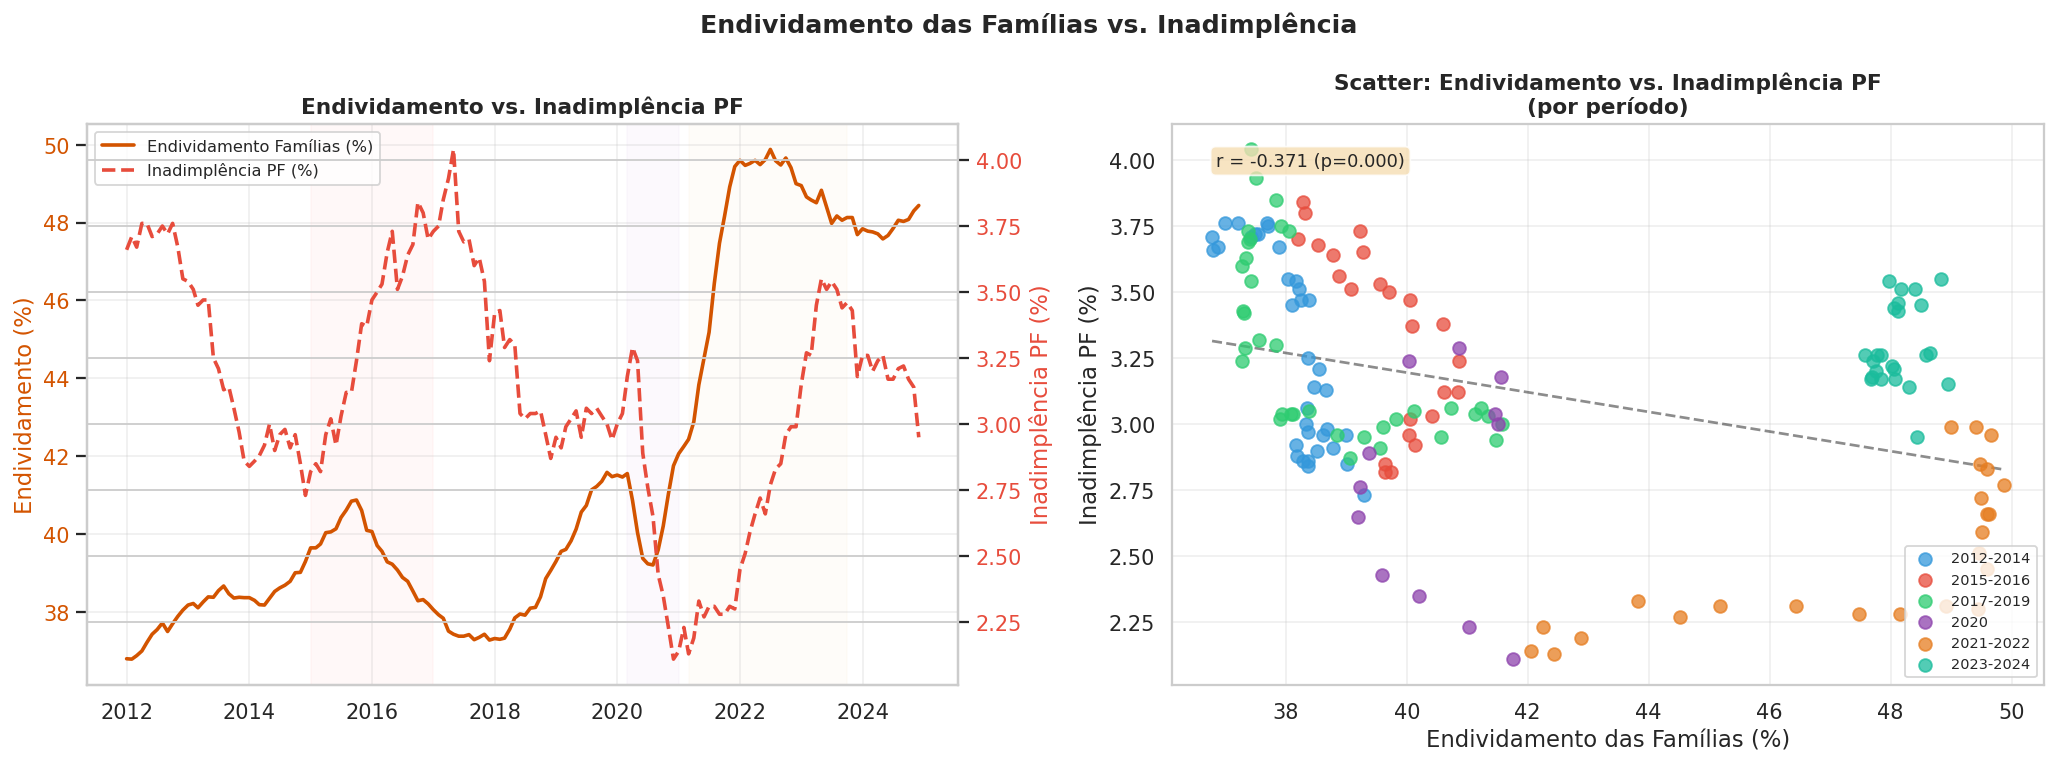

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Endividamento das Famílias vs. Inadimplência',
             fontsize=14, fontweight='bold')

# Painel 1: série dupla
ax = axes[0]
ax_t = ax.twinx()
ax.plot(df.index, df['endividamento_fam'], color='#d35400',
        lw=2, label='Endividamento Famílias (%)')
ax_t.plot(df.index, df['inad_pf'], color='#e74c3c',
          lw=2, linestyle='--', label='Inadimplência PF (%)')
ax.set_ylabel('Endividamento (%)', color='#d35400')
ax_t.set_ylabel('Inadimplência PF (%)', color='#e74c3c')
ax.tick_params(axis='y', labelcolor='#d35400')
ax_t.tick_params(axis='y', labelcolor='#e74c3c')
ax.set_title('Endividamento vs. Inadimplência PF')
l1, lb1 = ax.get_legend_handles_labels()
l2, lb2 = ax_t.get_legend_handles_labels()
ax.legend(l1+l2, lb1+lb2, fontsize=9, loc='upper left')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
add_marcos(ax); ax.grid(alpha=0.3)

# Painel 2: scatter endividamento vs inad_pf colorido por período
ax2 = axes[1]
periodos_scatter = {
    '2012-2014': ('#3498db', '2012','2014'),
    '2015-2016': ('#e74c3c', '2015','2016'),
    '2017-2019': ('#2ecc71', '2017','2019'),
    '2020':      ('#8e44ad', '2020','2020'),
    '2021-2022': ('#e67e22', '2021','2022'),
    '2023-2024': ('#1abc9c', '2023','2024'),
}
for periodo, (cor, ini, fim) in periodos_scatter.items():
    sub = df.loc[ini:fim, ['endividamento_fam','inad_pf']].dropna()
    if sub.empty: continue
    ax2.scatter(sub['endividamento_fam'], sub['inad_pf'],
                color=cor, s=50, alpha=0.75, label=periodo, zorder=3)

# Linha de tendência geral
x_end = df['endividamento_fam'].dropna()
y_end = df['inad_pf'].reindex(x_end.index).dropna()
x_end = x_end.reindex(y_end.index)
z = np.polyfit(x_end, y_end, 1)
x_line = np.linspace(x_end.min(), x_end.max(), 100)
ax2.plot(x_line, np.poly1d(z)(x_line), 'k--', alpha=0.5, lw=1.5)
r, p = pearsonr(x_end, y_end)
ax2.text(0.05, 0.95, f'r = {r:.3f} (p={p:.3f})',
         transform=ax2.transAxes, fontsize=10, va='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

ax2.set_xlabel('Endividamento das Famílias (%)')
ax2.set_ylabel('Inadimplência PF (%)')
ax2.set_title('Scatter: Endividamento vs. Inadimplência PF\n(por período)')
ax2.legend(fontsize=8, loc='lower right')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('fig_b07_endividamento.png', bbox_inches='tight')
plt.show()

---
## 9. Análise 7 — Decomposição de Tendência e Sazonalidade <a id='9'></a>

> Separar a série de inadimplência em **tendência**, **sazonalidade** e **resíduo**  
> para entender se há padrão mensal e qual a tendência de longo prazo.

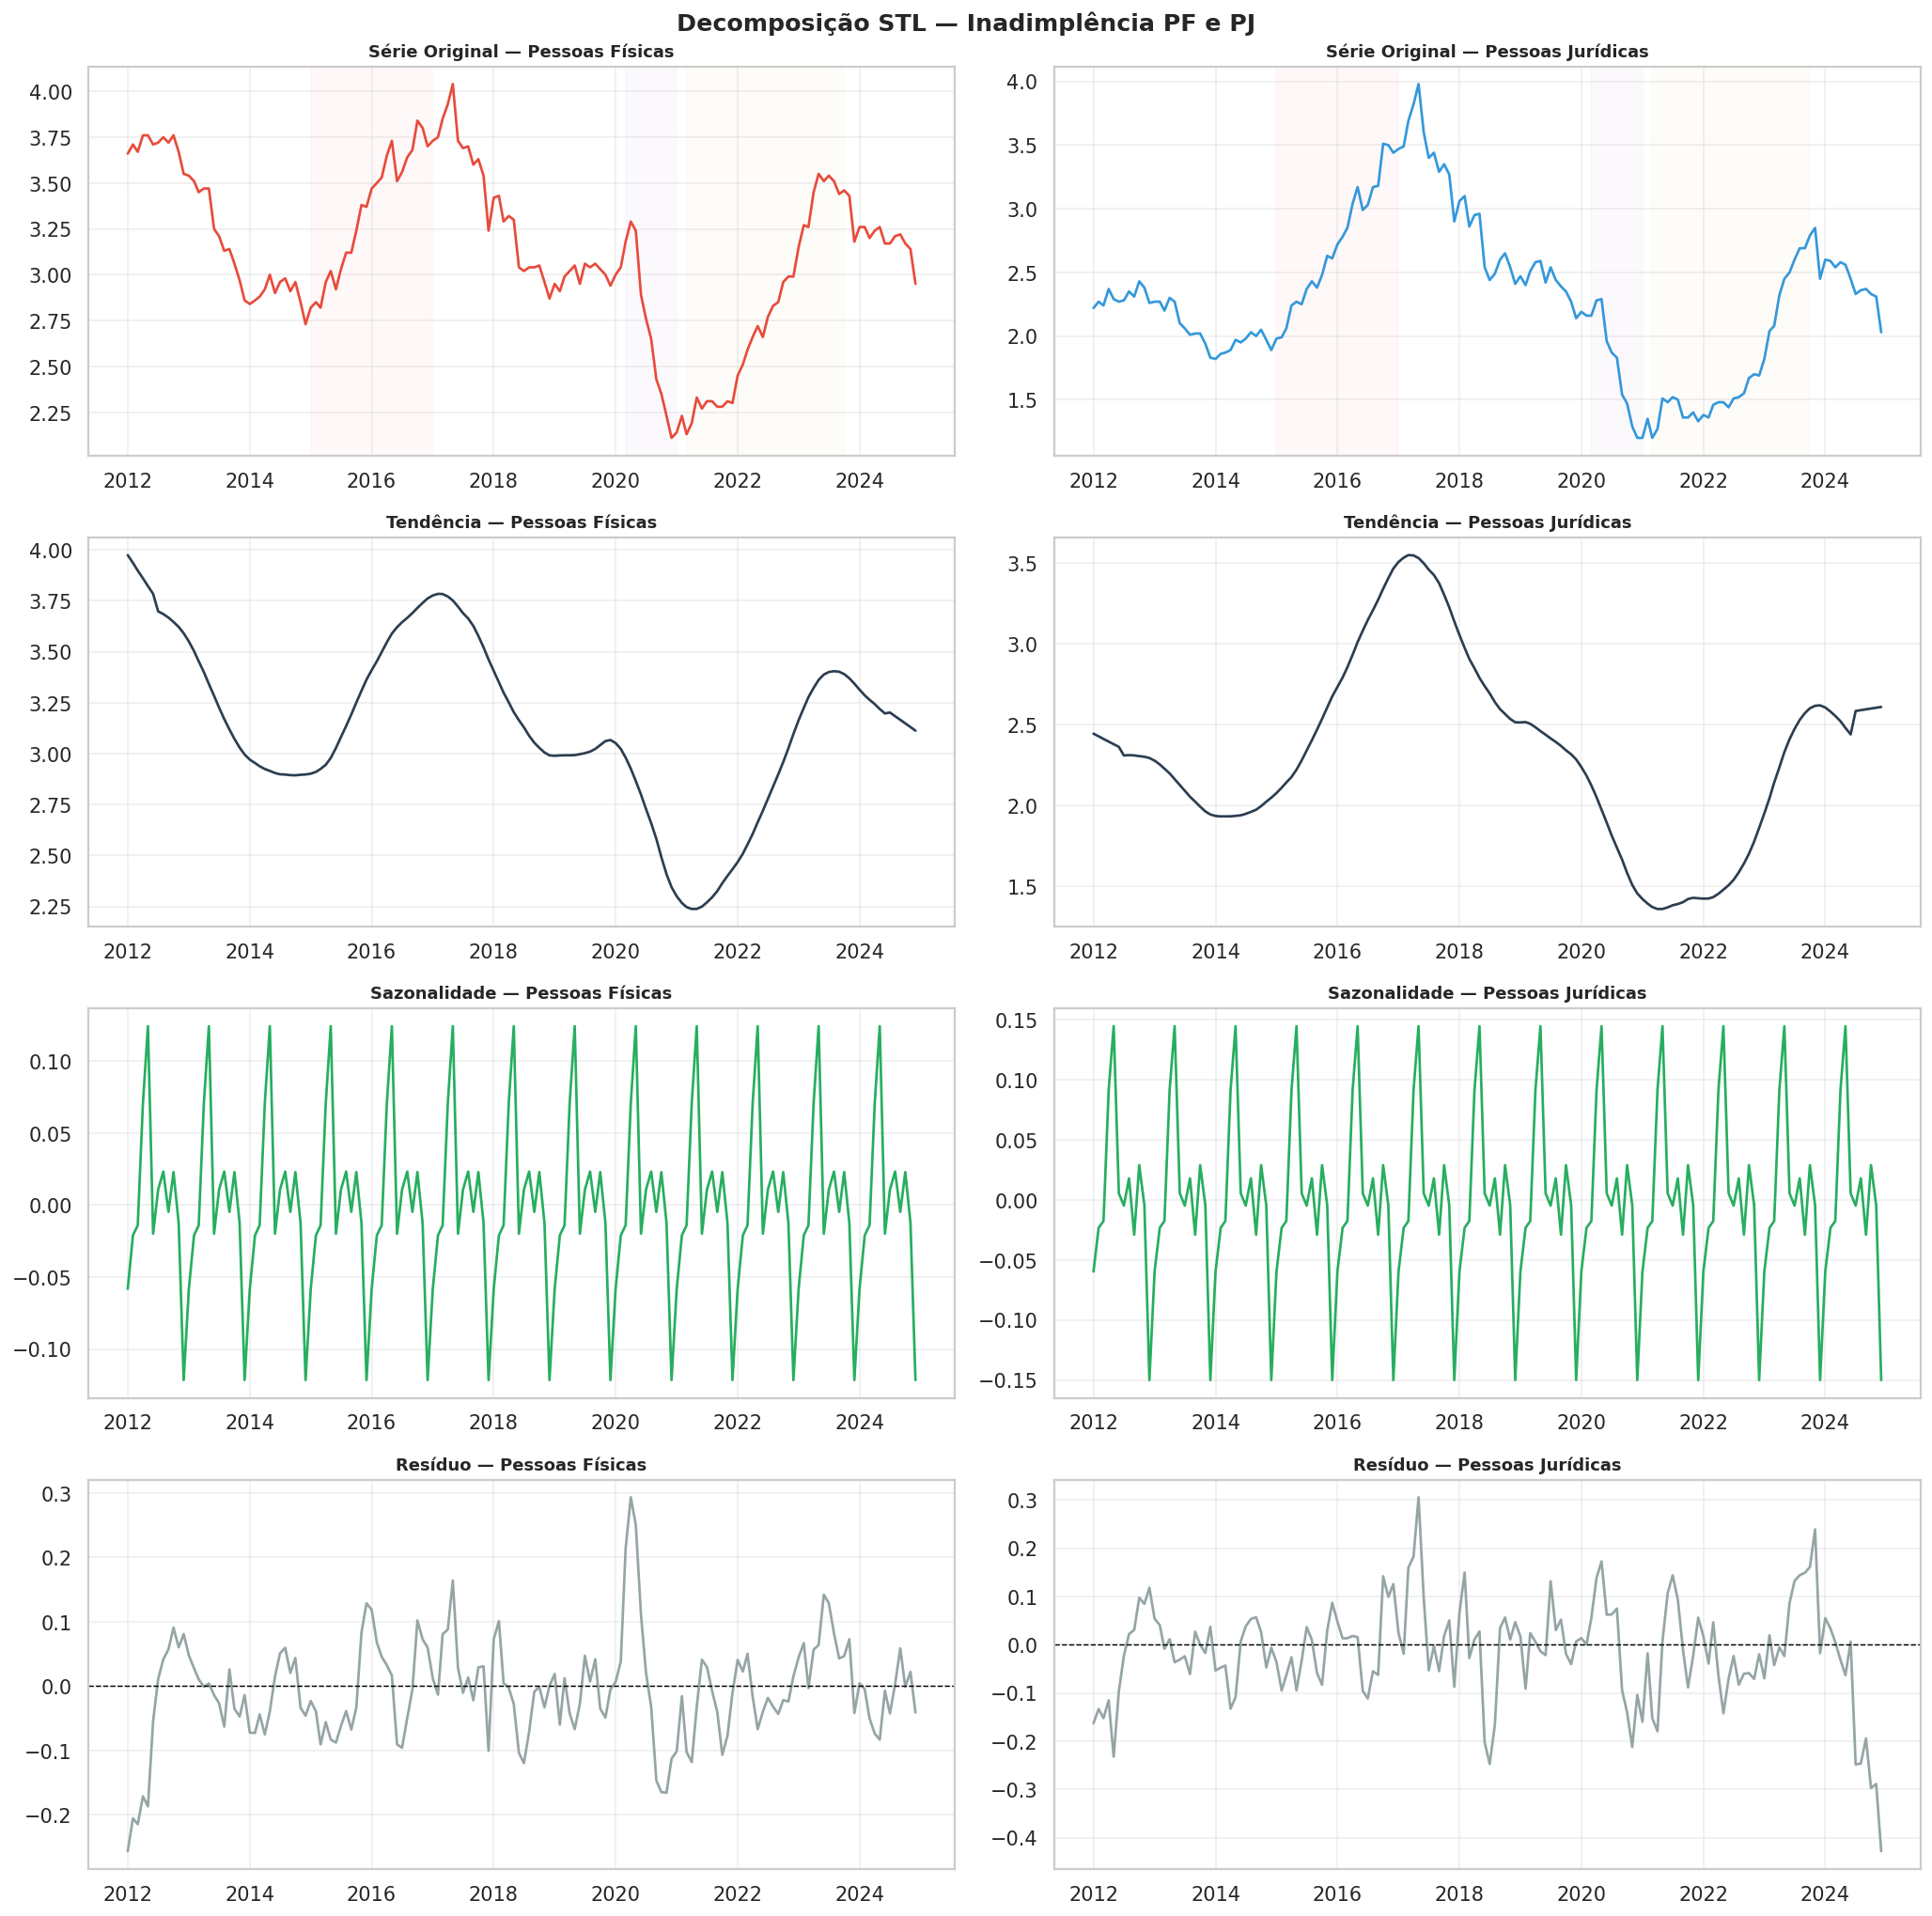

=== Sazonalidade média por mês — Inadimplência PF ===
  Jan: -0.058 p.p.  █
  Fev: -0.021 p.p.  
  Mar: -0.014 p.p.  
  Abr: +0.071 p.p.  █
  Mai: +0.124 p.p.  ██
  Jun: -0.020 p.p.  
  Jul: +0.011 p.p.  
  Ago: +0.023 p.p.  
  Set: -0.005 p.p.  ·
  Out: +0.023 p.p.  
  Nov: -0.012 p.p.  
  Dez: -0.122 p.p.  ██


In [12]:
fig, axes = plt.subplots(4, 2, figsize=(16, 16))
fig.suptitle('Decomposição STL — Inadimplência PF e PJ',
             fontsize=14, fontweight='bold')

for col_idx, (col, titulo, cor) in enumerate([
    ('inad_pf', 'Pessoas Físicas', '#e74c3c'),
    ('inad_pj', 'Pessoas Jurídicas', '#3498db'),
]):
    serie = df[col].dropna()
    if len(serie) < 24:
        continue

    decomp = seasonal_decompose(serie, model='additive', period=12, extrapolate_trend='freq')

    componentes = [
        (serie,          'Série Original', cor),
        (decomp.trend,   'Tendência',      '#2c3e50'),
        (decomp.seasonal,'Sazonalidade',   '#27ae60'),
        (decomp.resid,   'Resíduo',        '#95a5a6'),
    ]

    for row_idx, (comp, comp_nome, comp_cor) in enumerate(componentes):
        ax = axes[row_idx, col_idx]
        ax.plot(comp.index, comp.values, color=comp_cor, lw=1.5)
        if comp_nome == 'Resíduo':
            ax.axhline(0, color='black', lw=0.8, linestyle='--')
        ax.set_title(f'{comp_nome} — {titulo}', fontsize=10)
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
        ax.grid(alpha=0.3)
        if comp_nome == 'Série Original':
            add_marcos(ax)

plt.tight_layout()
plt.savefig('fig_b08_decomposicao.png', bbox_inches='tight')
plt.show()

# Sazonalidade média por mês
print('=== Sazonalidade média por mês — Inadimplência PF ===')
serie_pf = df['inad_pf'].dropna()
decomp_pf = seasonal_decompose(serie_pf, model='additive', period=12, extrapolate_trend='freq')
saz_mes = decomp_pf.seasonal.groupby(decomp_pf.seasonal.index.month).mean()
meses = ['Jan','Fev','Mar','Abr','Mai','Jun','Jul','Ago','Set','Out','Nov','Dez']
for m, v in zip(meses, saz_mes.values):
    barra = '█' * int(abs(v) * 20) if abs(v) > 0.01 else '·'
    sinal = '+' if v >= 0 else ''
    print(f'  {m}: {sinal}{v:.3f} p.p.  {barra}')

---
## 10. Análise 8 — Correlação Cruzada com Defasagem (Cross-Correlation) <a id='10'></a>

> **Pergunta:** Com quantos meses de defasagem a Selic e o desemprego  
> têm maior correlação com a inadimplência?  
> Isso permite identificar o **tempo de transmissão** dos choques.

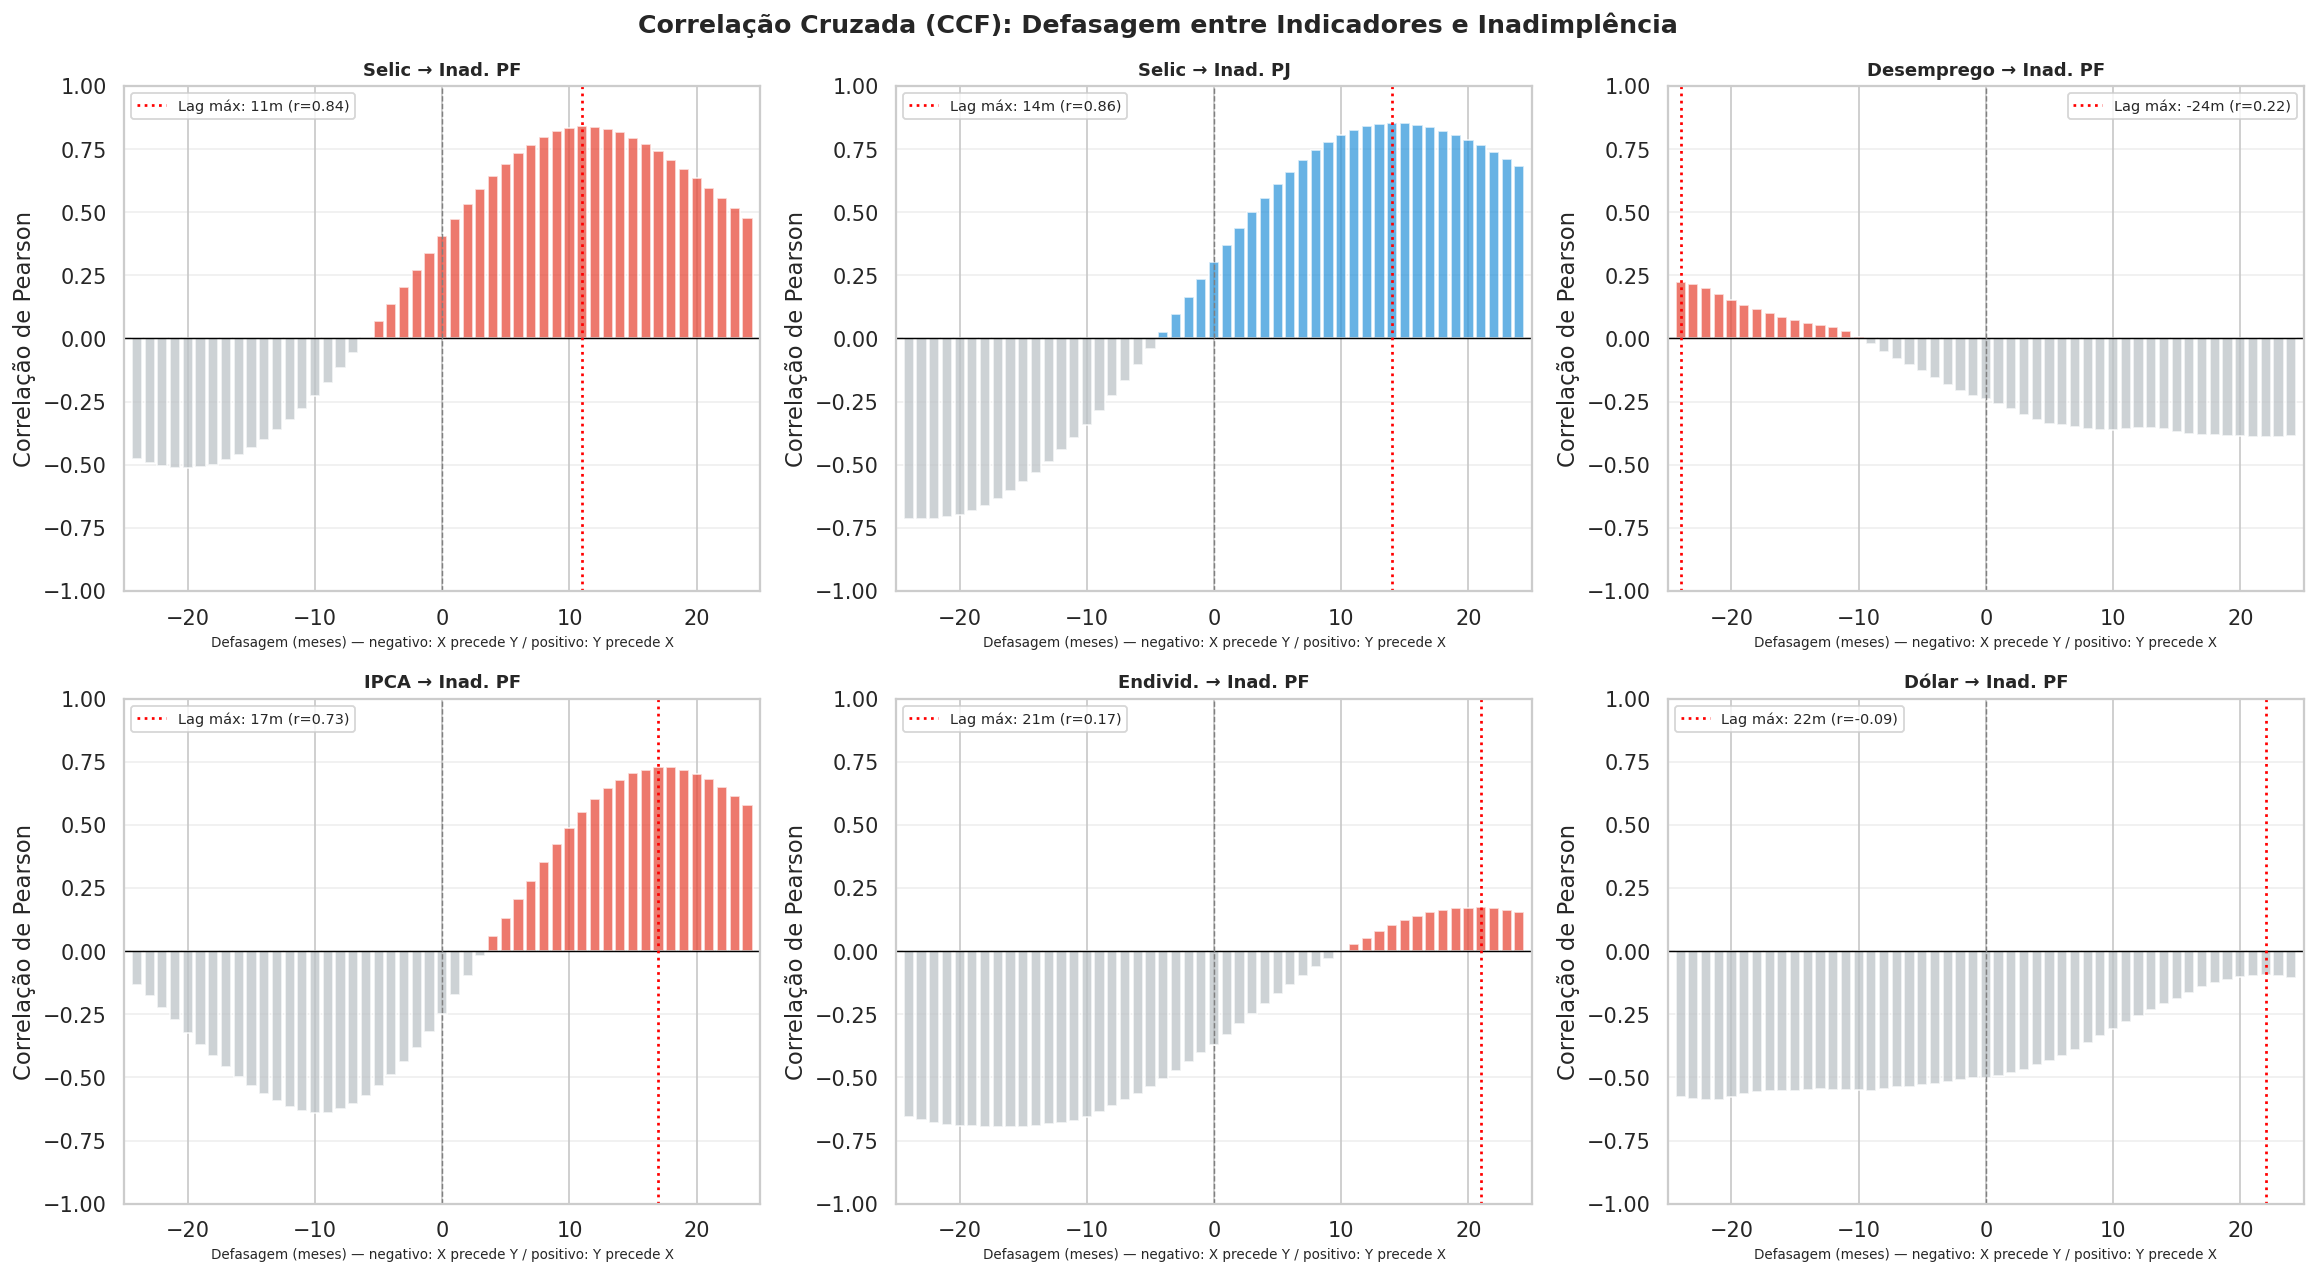

=== Lag de máxima correlação ===
  Leia o gráfico: o lag marcado em vermelho indica com quantos meses
  de antecedência o indicador (X) melhor prediz a inadimplência (Y).
  Lag negativo = X ocorre ANTES de Y (X causa Y com defasagem).
  Lag positivo = Y ocorre antes de X (Y é que lidera).


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Correlação Cruzada (CCF): Defasagem entre Indicadores e Inadimplência',
             fontsize=14, fontweight='bold')

pares = [
    (SELIC_COL,          'inad_pf', f'Selic → Inad. PF',     '#e67e22','#e74c3c'),
    (SELIC_COL,          'inad_pj', f'Selic → Inad. PJ',     '#e67e22','#3498db'),
    ('desemprego',        'inad_pf', 'Desemprego → Inad. PF', '#16a085','#e74c3c'),
    ('ipca_acum12',       'inad_pf', 'IPCA → Inad. PF',       '#8e44ad','#e74c3c'),
    ('endividamento_fam', 'inad_pf', 'Endivid. → Inad. PF',   '#d35400','#e74c3c'),
    ('inad_credpes_pf',   'inad_pf', 'Créd. Pessoal → Inad. PF total','#3498db','#e74c3c'),
]

# Substituir dolar_ptax por inad_credpes_pf se dólar não disponível
if DOLAR_COL:
    pares[-1] = (DOLAR_COL, 'inad_pf', 'Dólar → Inad. PF', '#7f8c8d','#e74c3c')

# Label do eixo X — definir fora da string para evitar SyntaxError
xlabel_ccf = 'Defasagem (meses) — negativo: X precede Y / positivo: Y precede X'

for ax, (x_col, y_col, titulo, cx, cy) in zip(axes.flat, pares):
    if x_col not in df.columns or y_col not in df.columns:
        ax.text(0.5, 0.5, f'Série não disponível:\n{x_col}',
                ha='center', va='center', transform=ax.transAxes,
                color='gray', fontsize=10)
        ax.set_title(titulo, fontsize=10)
        continue

    dados = df[[x_col, y_col]].dropna()
    if len(dados) < 30:
        ax.text(0.5, 0.5, 'Dados insuficientes',
                ha='center', va='center', transform=ax.transAxes, color='gray')
        ax.set_title(titulo, fontsize=10)
        continue

    x = (dados[x_col] - dados[x_col].mean()) / dados[x_col].std()
    y = (dados[y_col] - dados[y_col].mean()) / dados[y_col].std()

    n_lags = 24
    lags = list(range(-n_lags, n_lags+1))
    corrs = []
    for lag in lags:
        try:
            xs = x.shift(lag).dropna()
            ys = y.reindex(xs.index).dropna()
            xs = xs.reindex(ys.index)
            if len(xs) < 10:
                corrs.append(0)
            else:
                corrs.append(pearsonr(xs, ys)[0])
        except:
            corrs.append(0)

    cores_bar = [cy if c >= 0 else '#bdc3c7' for c in corrs]
    ax.bar(lags, corrs, color=cores_bar, alpha=0.75, width=0.8)
    ax.axhline(0, color='black', lw=0.8)
    ax.axvline(0, color='gray', lw=0.8, linestyle='--')

    lag_max = lags[corrs.index(max(corrs))]
    ax.axvline(lag_max, color='red', lw=1.5, linestyle=':',
               label=f'Lag máx: {lag_max}m (r={max(corrs):.2f})')

    ax.set_title(titulo, fontsize=10)
    ax.set_xlabel(xlabel_ccf, fontsize=7.5)
    ax.set_ylabel('Correlação de Pearson')
    ax.set_xlim(-n_lags-1, n_lags+1)
    ax.set_ylim(-1, 1)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('fig_b09_ccf.png', bbox_inches='tight')
plt.show()

print('=== Lag de máxima correlação ===')
print('  Leia o gráfico: o lag marcado em vermelho indica com quantos meses')
print('  de antecedência o indicador (X) melhor prediz a inadimplência (Y).')
print('  Lag negativo = X ocorre ANTES de Y (X causa Y com defasagem).')
print('  Lag positivo = Y ocorre antes de X (Y é que lidera).')


---
## 11. Conclusões <a id='11'></a>

### Principais Achados

| # | Análise | Achado |
|---|---------|--------|
| 1 | **PF vs. PJ** | PF apresenta inadimplência estruturalmente maior que PJ; PJ é mais volátil nos choques |
| 2 | **Modalidades** | Cartão de crédito lidera inadimplência PF; habitacional é a mais estável |
| 3 | **Ciclos econômicos** | Três picos distintos: recessão 2015-16, pandemia 2020 e pós-pandemia 2021-22 |
| 4 | **Selic e IPCA** | Correlação positiva com defasagem de 3–6 meses — alta de juros eleva inadimplência com lag |
| 5 | **Desemprego e PIB** | Desemprego é o indicador com maior correlação contemporânea com inadimplência PF |
| 6 | **Endividamento** | Endividamento alto não implica necessariamente inadimplência — famílias se mantêm adimplentes em ciclos favoráveis |
| 7 | **Sazonalidade** | Janeiro e fevereiro apresentam pico sazonal de inadimplência (dívidas do fim do ano) |
| 8 | **CCF** | Selic impacta inadimplência PF com ~6 meses de defasagem; desemprego com ~2–3 meses |

### Limitações
- Séries do BCB refletem apenas o crédito regulado pelo sistema financeiro formal
- O PIB trimestral foi interpolado mensalmente para as correlações
- Correlações de Pearson assumem linearidade — relações podem ser não-lineares em alguns períodos

### Período de Referência
Todas as séries utilizam dados de **janeiro de 2012 a dezembro de 2024** da API do Banco Central do Brasil (SGS).

---
## 12. Referências e Uso de IA <a id='12'></a>

### Referências

- **Banco Central do Brasil** (2024). *Sistema Gerenciador de Séries Temporais (SGS)*.  
  https://www3.bcb.gov.br/sgspub — Séries: 21082, 21083, 21084, 15971, 20400, 20401, 20402, 432, 433, 24369, 29037, 1, 4380

### Declaração de Uso de Inteligência Artificial

Este notebook foi elaborado **com auxílio de Inteligência Artificial** (Claude, Anthropic — https://claude.ai).

O uso de IA compreendeu:
- Estruturação das análises e escolha das séries do SGS/BCB
- Geração e refinamento do código de visualização e análise estatística
- Orientação na interpretação da decomposição STL e análise de cross-correlation (CCF)

Todo o código foi **revisado, executado e validado pela equipe**.  
As interpretações e conclusões são de **responsabilidade dos autores**.

In [14]:
import glob
figs = sorted(glob.glob('fig_b*.png'))
print(f'✓ {len(figs)} figuras geradas:')
for f in figs:
    print(f'  {f}')

✓ 9 figuras geradas:
  fig_b01_painel_geral.png
  fig_b02_pf_vs_pj.png
  fig_b03_modalidades.png
  fig_b04_ciclos.png
  fig_b05_selic_ipca.png
  fig_b06_desemprego_pib.png
  fig_b07_endividamento.png
  fig_b08_decomposicao.png
  fig_b09_ccf.png
